<a href="https://colab.research.google.com/github/Alhmmada/Bike-Sharing-Demand-Prediction/blob/main/AH2179_Final_Project_Bus_176_177_Delay_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Delay Prediction for Stockholm Bus Routes 176 and 177

## AH2179 – Applied Artificial Intelligence in Transportation

### Project objective

This project develops and compares machine-learning models for predicting
next-stop arrival delays on Stockholm bus routes 176 and 177.

The study uses scheduled and observed stop-level arrival and departure data
from 2024. It also examines when and where delays accumulate along the two
routes and whether excessive dwell times at important stops are associated
with increasing downstream delays.

Routes 176 and 177 were selected because they are important blue trunk bus
routes connecting Ekerö with major interchange locations in western and
northern Stockholm. In November 2025, SL introduced boarding through all doors
on these routes to improve boarding efficiency and reduce queues at the front
door. Since the available dataset covers 2024, it represents a
pre-implementation baseline. The project does not estimate the causal effect
of the 2025 intervention.

### Main research question

How accurately can machine-learning models predict next-stop arrival delays
on Stockholm bus routes 176 and 177, and at which stops and time periods do
delays accumulate most strongly?

### Sub-questions

1. At which stops, directions and times of day are delays largest?
2. How strongly does delay at the previous stop predict delay at the next stop?
3. Are long stop dwell times associated with increasing downstream delay?
4. Which of the selected prediction models performs best?
5. Does model performance differ between routes, directions and months?

### Hypotheses

- H1: Delay at the previous stop is the strongest predictor of next-stop delay.
- H2: Delays and dwell times are larger during peak periods.
- H3: A limited number of important interchange stops account for a large
  share of delay accumulation.
- H4: Tree-based models outperform linear regression because delay development
  contains nonlinear relationships.
  

## 1. Data collection

The primary dataset contains scheduled and observed vehicle arrival and
departure events collected from SL GTFS-Realtime TripUpdates during 2024 and
merged with the corresponding static GTFS schedules.

The initial data validation is performed using January 2024. Only observations
for bus routes 176 and 177 are retained. After validating the variables,
coverage and data quality, the same preprocessing procedure will be applied
to all twelve months.

Source: KTH Data Repository  
Dataset DOI: https://doi.org/10.71775/kth.f50j9-fkg32

In [3]:
# Connect Colab to Google Drive and create an isolated project folder

from google.colab import drive
from pathlib import Path
import requests

drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/AH2179_Final_Project_Bus_176_177"
)

RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
FIGURES_DIR = PROJECT_DIR / "figures"
MODELS_DIR = PROJECT_DIR / "models"

for folder in [
    RAW_DIR,
    PROCESSED_DIR,
    FIGURES_DIR,
    MODELS_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folder:", PROJECT_DIR)
print("Project folders created successfully.")

Mounted at /content/drive
Project folder: /content/drive/MyDrive/AH2179_Final_Project_Bus_176_177
Project folders created successfully.


In [4]:
# Download January 2024 and the static reference files

BASE_URL = (
    "https://datarepository.kth.se/records/"
    "f50j9-fkg32/files"
)

files = [
    "gtfs_rt_202401.csv.gz",
    "routes.csv",
    "trips.csv",
    "stops.csv"
]

for filename in files:

    output_path = RAW_DIR / filename

    if output_path.exists():
        size_mb = output_path.stat().st_size / 1024**2
        print(
            f"{filename}: already downloaded "
            f"({size_mb:.1f} MB)"
        )
        continue

    url = f"{BASE_URL}/{filename}?download=1"

    print(f"Downloading {filename}...")

    with requests.get(url, stream=True) as response:
        response.raise_for_status()

        with open(output_path, "wb") as file:
            for block in response.iter_content(
                chunk_size=1024 * 1024
            ):
                if block:
                    file.write(block)

    size_mb = output_path.stat().st_size / 1024**2
    print(f"{filename}: downloaded ({size_mb:.1f} MB)")

print("\nAll initial files are available.")

gtfs_rt_202401.csv.gz: already downloaded (327.7 MB)
routes.csv: already downloaded (0.0 MB)
trips.csv: already downloaded (17.1 MB)
stops.csv: already downloaded (1.3 MB)

All initial files are available.


In [5]:
import gzip

january_file = RAW_DIR / "gtfs_rt_202401.csv.gz"

with gzip.open(
    january_file,
    mode="rt",
    encoding="utf-8-sig"
) as file:
    header = file.readline()

print("Raw header:")
print(repr(header))

print("\nHeader displayed normally:")
print(header)

Raw header:
'date;LineNumber;LineID;route_id;TransportMode;direction_id;trip_id;VehicleID;shape_id;planned_departure_sfm;planned_departure_tripupdates_sfm;stop_sequence;dist_traveled;previous_stop_id;previous_StopAreaID;observed_stop_id;observed_StopAreaID;scheduled_arrival_time_sfm;observed_arrival_time_sfm;observed_arrival_delay;observed_arrival_uncertainty;scheduled_departure_time_sfm;observed_departure_time_sfm;observed_departure_delay;observed_departure_uncertainty;tripupdates_and_gtfs_not_merged_within_service_id;tripupdates_not_merged_with_stoptimes_or_trip;stop_headsign\n'

Header displayed normally:
date;LineNumber;LineID;route_id;TransportMode;direction_id;trip_id;VehicleID;shape_id;planned_departure_sfm;planned_departure_tripupdates_sfm;stop_sequence;dist_traveled;previous_stop_id;previous_StopAreaID;observed_stop_id;observed_StopAreaID;scheduled_arrival_time_sfm;observed_arrival_time_sfm;observed_arrival_delay;observed_arrival_uncertainty;scheduled_departure_time_sfm;observ

## 2. Initial filtering: bus routes 176 and 177

The January dataset is read in chunks to reduce memory usage. Only bus
observations belonging to routes 176 and 177 are retained. The filtered
dataset is saved in Parquet format for faster subsequent analysis.

In [6]:
import pandas as pd

january_file = RAW_DIR / "gtfs_rt_202401.csv.gz"

selected_chunks = []
total_rows = 0
selected_rows = 0

for chunk_number, chunk in enumerate(
    pd.read_csv(
        january_file,
        sep=";",
        compression="gzip",
        chunksize=500_000,
        dtype={"LineNumber": "string"},
        low_memory=False
    ),
    start=1
):
    total_rows += len(chunk)

    # Standardize text variables
    chunk["LineNumber"] = (
        chunk["LineNumber"]
        .str.strip()
    )

    chunk["TransportMode"] = (
        chunk["TransportMode"]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    # Keep bus routes 176 and 177
    selected = chunk[
        (chunk["TransportMode"] == "BUS")
        & (chunk["LineNumber"].isin(["176", "177"]))
    ].copy()

    if not selected.empty:
        selected_chunks.append(selected)
        selected_rows += len(selected)

    print(
        f"Chunk {chunk_number}: "
        f"{len(chunk):,} total rows, "
        f"{len(selected):,} selected"
    )

if not selected_chunks:
    raise ValueError(
        "No observations were found for routes 176 and 177."
    )

# Combine all selected observations
jan_176_177 = pd.concat(
    selected_chunks,
    ignore_index=True
)

# Convert date variable
jan_176_177["date"] = pd.to_datetime(
    jan_176_177["date"],
    errors="coerce"
)

# Save filtered January dataset
output_file = (
    PROCESSED_DIR /
    "bus_176_177_202401.parquet"
)

jan_176_177.to_parquet(
    output_file,
    index=False
)

print("\nFILTERING COMPLETED")
print(f"Rows examined: {total_rows:,}")
print(f"Rows retained: {selected_rows:,}")
print(f"Columns: {jan_176_177.shape[1]}")

print(
    "Date range:",
    jan_176_177["date"].min().date(),
    "to",
    jan_176_177["date"].max().date()
)

print(f"Saved to: {output_file}")

print("\nObservations by route and direction:")

route_summary = (
    jan_176_177
    .groupby(
        ["LineNumber", "direction_id"],
        dropna=False
    )
    .size()
    .reset_index(name="observations")
)

display(route_summary)

print("\nFirst five observations:")
display(jan_176_177.head())

Chunk 1: 500,000 total rows, 6,563 selected
Chunk 2: 500,000 total rows, 8,035 selected
Chunk 3: 500,000 total rows, 8,035 selected
Chunk 4: 500,000 total rows, 8,035 selected
Chunk 5: 500,000 total rows, 8,035 selected
Chunk 6: 500,000 total rows, 0 selected
Chunk 7: 500,000 total rows, 13,126 selected
Chunk 8: 500,000 total rows, 8,035 selected
Chunk 9: 500,000 total rows, 0 selected
Chunk 10: 500,000 total rows, 8,035 selected
Chunk 11: 500,000 total rows, 8,035 selected
Chunk 12: 500,000 total rows, 8,035 selected
Chunk 13: 500,000 total rows, 0 selected
Chunk 14: 500,000 total rows, 8,035 selected
Chunk 15: 500,000 total rows, 6,563 selected
Chunk 16: 500,000 total rows, 6,563 selected
Chunk 17: 500,000 total rows, 8,035 selected
Chunk 18: 500,000 total rows, 8,035 selected
Chunk 19: 500,000 total rows, 0 selected
Chunk 20: 500,000 total rows, 8,035 selected
Chunk 21: 500,000 total rows, 8,035 selected
Chunk 22: 500,000 total rows, 8,035 selected
Chunk 23: 500,000 total rows, 0 se

,LineNumber,direction_id,observations
0,176,0,66942
1,176,1,62248
2,177,0,54440
3,177,1,52054



First five observations:


,date,LineNumber,LineID,route_id,TransportMode,direction_id,trip_id,VehicleID,shape_id,planned_departure_sfm,...,observed_arrival_time_sfm,observed_arrival_delay,observed_arrival_uncertainty,scheduled_departure_time_sfm,observed_departure_time_sfm,observed_departure_delay,observed_departure_uncertainty,tripupdates_and_gtfs_not_merged_within_service_id,tripupdates_not_merged_with_stoptimes_or_trip,stop_headsign
0,1970-01-01 00:00:00.020240101,176,9011001017600000,9011001017600000,BUS,0,14010000640347669,9.031001e+15,1014010000628714328,23880,...,23967.0,87.0,NaN,23880.0,23990.0,110.0,0.0,f,f,Stenhamra
1,1970-01-01 00:00:00.020240101,176,9011001017600000,9011001017600000,BUS,0,14010000640347669,9.031001e+15,1014010000628714328,23880,...,24089.0,89.0,0.0,24000.0,24118.0,118.0,0.0,f,f,Stenhamra
2,1970-01-01 00:00:00.020240101,176,9011001017600000,9011001017600000,BUS,0,14010000640347669,9.031001e+15,1014010000628714328,23880,...,24285.0,147.0,0.0,24138.0,24285.0,147.0,0.0,f,f,Stenhamra
3,1970-01-01 00:00:00.020240101,176,9011001017600000,9011001017600000,BUS,0,14010000640347669,9.031001e+15,1014010000628714328,23880,...,24444.0,172.0,0.0,24272.0,24456.0,184.0,0.0,f,f,Stenhamra
4,1970-01-01 00:00:00.020240101,176,9011001017600000,9011001017600000,BUS,0,14010000640347669,9.031001e+15,1014010000628714328,23880,...,24542.0,191.0,0.0,24351.0,24542.0,191.0,0.0,f,f,Stenhamra


In [7]:
# Correct the date format and overwrite the filtered file

# Recover YYYYMMDD values from the incorrectly parsed timestamps
if pd.api.types.is_datetime64_any_dtype(jan_176_177["date"]):
    raw_date = (
        jan_176_177["date"]
        .astype("int64")
        .astype("string")
    )
else:
    raw_date = (
        jan_176_177["date"]
        .astype("string")
        .str.replace(r"\.0$", "", regex=True)
    )

jan_176_177["date"] = pd.to_datetime(
    raw_date,
    format="%Y%m%d",
    errors="coerce"
)

# Verify the correction
print("Corrected date range:")
print(
    jan_176_177["date"].min(),
    "to",
    jan_176_177["date"].max()
)

print(
    "Missing dates:",
    jan_176_177["date"].isna().sum()
)

print("\nFirst five dates:")
display(jan_176_177[["date", "LineNumber"]].head())

# Overwrite the previous Parquet file
jan_176_177.to_parquet(
    output_file,
    index=False
)

print("\nCorrected dataset saved successfully.")

Corrected date range:
2024-01-01 00:00:00 to 2024-01-31 00:00:00
Missing dates: 0

First five dates:


,date,LineNumber
0,2024-01-01,176
1,2024-01-01,176
2,2024-01-01,176
3,2024-01-01,176
4,2024-01-01,176



Corrected dataset saved successfully.


## 3. Data quality assessment

Before cleaning the dataset, its completeness, matching quality, duplicate
observations and delay distributions are examined. This ensures that any
filtering decisions are transparent and justified.

In [8]:
# Initial data-quality assessment

import numpy as np
import pandas as pd

print("DATASET OVERVIEW")
print(f"Rows: {len(jan_176_177):,}")
print(f"Columns: {jan_176_177.shape[1]}")
print(f"Service days: {jan_176_177['date'].nunique()}")
print(f"Unique trips: {jan_176_177['trip_id'].nunique():,}")
print(f"Unique vehicles: {jan_176_177['VehicleID'].nunique():,}")
print(f"Unique observed stops: {jan_176_177['observed_stop_id'].nunique():,}")

# Variables important for analysis and modelling
important_columns = [
    "date",
    "LineNumber",
    "direction_id",
    "trip_id",
    "VehicleID",
    "stop_sequence",
    "dist_traveled",
    "previous_stop_id",
    "observed_stop_id",
    "scheduled_arrival_time_sfm",
    "observed_arrival_time_sfm",
    "observed_arrival_delay",
    "scheduled_departure_time_sfm",
    "observed_departure_time_sfm",
    "observed_departure_delay"
]

missing_summary = pd.DataFrame({
    "missing_count": jan_176_177[important_columns].isna().sum(),
    "missing_percent": (
        jan_176_177[important_columns]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    )
}).sort_values("missing_percent", ascending=False)

print("\nMISSING VALUES")
display(missing_summary)

# Matching-quality flags
quality_flags = [
    "tripupdates_and_gtfs_not_merged_within_service_id",
    "tripupdates_not_merged_with_stoptimes_or_trip"
]

print("\nMATCHING FLAGS")

for column in quality_flags:
    print(f"\n{column}:")
    display(
        jan_176_177[column]
        .value_counts(dropna=False)
        .rename_axis("value")
        .reset_index(name="observations")
    )

# Exact duplicate rows
exact_duplicates = jan_176_177.duplicated().sum()

# Duplicate trip-stop keys
trip_stop_key = [
    "date",
    "route_id",
    "trip_id",
    "direction_id",
    "stop_sequence",
    "observed_stop_id"
]

key_duplicates = jan_176_177.duplicated(
    subset=trip_stop_key,
    keep=False
).sum()

print("\nDUPLICATES")
print(f"Exact duplicate rows: {exact_duplicates:,}")
print(f"Rows with duplicated trip-stop keys: {key_duplicates:,}")

# Delay distributions
delay_columns = [
    "observed_arrival_delay",
    "observed_departure_delay"
]

delay_summary = (
    jan_176_177[delay_columns]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
    .T
)

print("\nDELAY DISTRIBUTIONS IN SECONDS")
display(delay_summary.round(2))

# Preliminary count of very large delay values
extreme_summary = pd.DataFrame({
    "below_minus_30_min": [
        (jan_176_177[column] < -1800).sum()
        for column in delay_columns
    ],
    "above_plus_30_min": [
        (jan_176_177[column] > 1800).sum()
        for column in delay_columns
    ]
}, index=delay_columns)

print("\nPRELIMINARY EXTREME VALUES")
display(extreme_summary)

DATASET OVERVIEW
Rows: 235,684
Columns: 28
Service days: 31
Unique trips: 441
Unique vehicles: 28
Unique observed stops: 103

MISSING VALUES


,missing_count,missing_percent
observed_departure_time_sfm,1199,0.51
observed_departure_delay,1199,0.51
observed_arrival_time_sfm,1186,0.50
observed_arrival_delay,1186,0.50
VehicleID,693,0.29
LineNumber,0,0.00
date,0,0.00
dist_traveled,0,0.00
stop_sequence,0,0.00
trip_id,0,0.00



MATCHING FLAGS

tripupdates_and_gtfs_not_merged_within_service_id:


,value,observations
0,f,235684



tripupdates_not_merged_with_stoptimes_or_trip:


,value,observations
0,f,235684



DUPLICATES
Exact duplicate rows: 0
Rows with duplicated trip-stop keys: 0

DELAY DISTRIBUTIONS IN SECONDS


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
observed_arrival_delay,234498.0,179.06,263.01,-1200.0,-262.0,-112.0,24.0,119.0,275.0,654.0,1084.0,5124.0
observed_departure_delay,234485.0,195.88,260.21,-1187.0,-206.0,-80.0,38.0,133.0,288.0,668.0,1098.0,5124.0



PRELIMINARY EXTREME VALUES


,below_minus_30_min,above_plus_30_min
observed_arrival_delay,0,392
observed_departure_delay,0,408


### Initial data-quality findings

The January dataset demonstrates high overall quality. Approximately 99.5%
of the observations contain an observed arrival delay, while all retained
records were successfully matched between GTFS and GTFS-Realtime. No exact
duplicates or duplicated trip-stop keys were identified.

The median arrival delay was 119 seconds, while the mean was 179 seconds.
The higher mean indicates a right-skewed distribution caused by a limited
number of severe delays. A total of 392 arrival observations exceeded
30 minutes. These observations are not automatically removed because they
may represent genuine disruptions. Their influence will later be examined
through sensitivity analysis as part of the model diagnostics.

### Data-quality visualisation

The following figures illustrate missing-data rates and the distribution of
arrival delays. The histogram and boxplots use restricted display ranges to
make the main patterns visible. This visual restriction does not remove
observations from the analytical dataset.

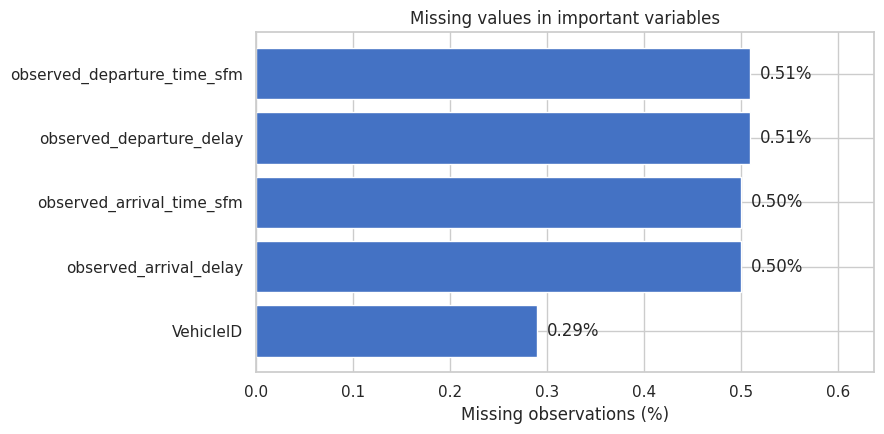

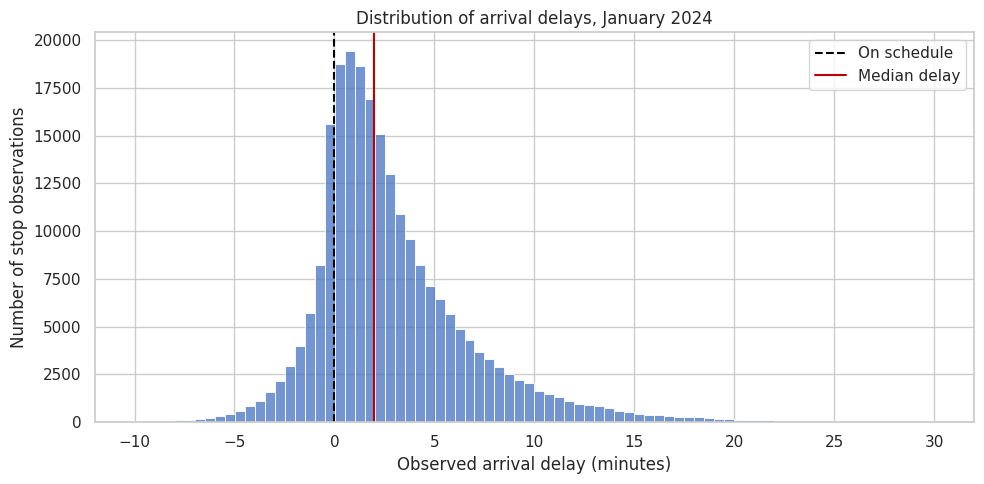

The displayed histogram contains 99.81% of non-missing observations.


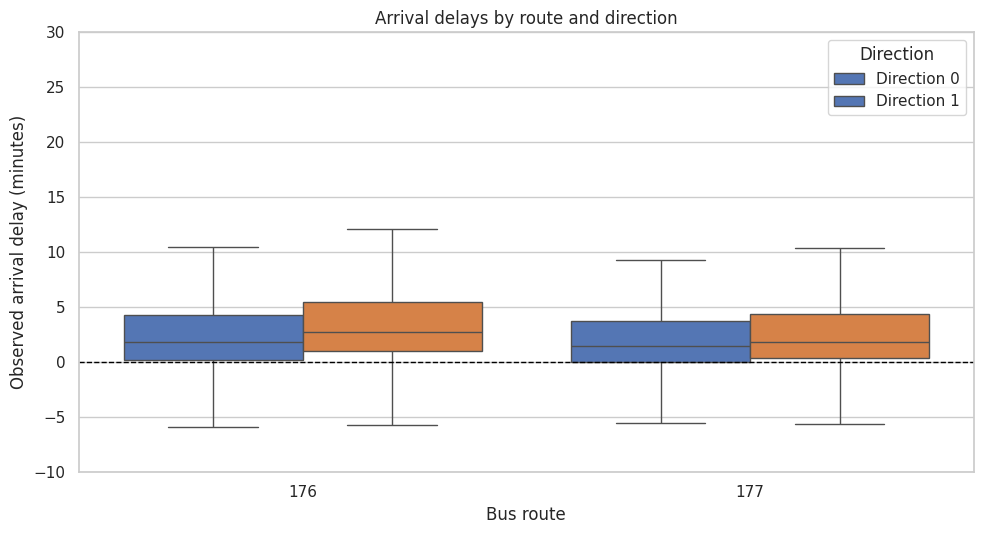


Figures saved in:
/content/drive/MyDrive/AH2179_Final_Project_Bus_176_177/figures


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

# Create delay variables expressed in minutes
jan_176_177["arrival_delay_min"] = (
    jan_176_177["observed_arrival_delay"] / 60
)

jan_176_177["departure_delay_min"] = (
    jan_176_177["observed_departure_delay"] / 60
)

# ---------------------------------------------------------
# Figure 1: Missing values
# ---------------------------------------------------------

missing_plot = (
    missing_summary[missing_summary["missing_percent"] > 0]
    .sort_values("missing_percent")
)

plt.figure(figsize=(9, 4.5))

plt.barh(
    missing_plot.index,
    missing_plot["missing_percent"],
    color="#4472C4"
)

plt.xlabel("Missing observations (%)")
plt.ylabel("")
plt.title("Missing values in important variables")

for index, value in enumerate(missing_plot["missing_percent"]):
    plt.text(
        value + 0.01,
        index,
        f"{value:.2f}%",
        va="center"
    )

plt.xlim(0, max(missing_plot["missing_percent"]) * 1.25)
plt.tight_layout()

missing_figure = FIGURES_DIR / "figure_missing_values_january.png"
plt.savefig(missing_figure, dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# Figure 2: Arrival-delay distribution
# Display range: -10 to +30 minutes
# ---------------------------------------------------------

delay_for_plot = jan_176_177[
    jan_176_177["arrival_delay_min"].between(-10, 30)
].copy()

display_share = (
    len(delay_for_plot)
    / jan_176_177["arrival_delay_min"].notna().sum()
    * 100
)

plt.figure(figsize=(10, 5))

sns.histplot(
    data=delay_for_plot,
    x="arrival_delay_min",
    bins=80,
    color="#4472C4",
    edgecolor=None
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="On schedule"
)

plt.axvline(
    jan_176_177["arrival_delay_min"].median(),
    color="#C00000",
    linestyle="-",
    linewidth=1.5,
    label="Median delay"
)

plt.xlabel("Observed arrival delay (minutes)")
plt.ylabel("Number of stop observations")
plt.title("Distribution of arrival delays, January 2024")
plt.legend()
plt.tight_layout()

histogram_figure = FIGURES_DIR / "figure_arrival_delay_distribution.png"
plt.savefig(histogram_figure, dpi=300, bbox_inches="tight")
plt.show()

print(
    f"The displayed histogram contains "
    f"{display_share:.2f}% of non-missing observations."
)

# ---------------------------------------------------------
# Figure 3: Comparison by route and direction
# Outliers remain in the dataset but are hidden in the plot
# ---------------------------------------------------------

plt.figure(figsize=(10, 5.5))

sns.boxplot(
    data=jan_176_177,
    x="LineNumber",
    y="arrival_delay_min",
    hue="direction_id",
    showfliers=False,
    palette=["#4472C4", "#ED7D31"]
)

plt.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.ylim(-10, 30)
plt.xlabel("Bus route")
plt.ylabel("Observed arrival delay (minutes)")
plt.title("Arrival delays by route and direction")
plt.legend(
    title="Direction",
    labels=["Direction 0", "Direction 1"]
)
plt.tight_layout()

boxplot_figure = FIGURES_DIR / "figure_delay_route_direction.png"
plt.savefig(boxplot_figure, dpi=300, bbox_inches="tight")
plt.show()

print("\nFigures saved in:")
print(FIGURES_DIR)

### Interpretation

Missing values account for less than 1% of the important observed variables,
indicating high data completeness. The arrival-delay distribution is
right-skewed: most observations are concentrated around relatively small
delays, while a limited number of observations represent severe disruptions.
The restricted histogram range still contains 99.81% of all non-missing
arrival-delay observations. Extreme observations remain in the dataset and
will later be examined through model diagnostics and sensitivity analysis.

## 4. Processing the complete 2024 dataset

After validating the January data, the same chunk-based filtering procedure
is applied consistently to all twelve months. Only observations for bus
routes 176 and 177 are retained. Each filtered monthly dataset is stored
separately in Parquet format to support reproducibility and efficient analysis.

In [10]:
from tqdm.auto import tqdm
import requests
import pandas as pd

TARGET_LINES = {"176", "177"}

def download_file(url, output_path):
    """Download a file safely using a temporary partial file."""

    if output_path.exists():
        print(f"{output_path.name}: already downloaded")
        return

    temporary_path = output_path.with_suffix(
        output_path.suffix + ".part"
    )

    with requests.get(url, stream=True) as response:
        response.raise_for_status()

        total_size = int(
            response.headers.get("content-length", 0)
        )

        with open(temporary_path, "wb") as file:
            with tqdm(
                total=total_size,
                unit="B",
                unit_scale=True,
                desc=output_path.name
            ) as progress:

                for block in response.iter_content(
                    chunk_size=1024 * 1024
                ):
                    if block:
                        file.write(block)
                        progress.update(len(block))

    temporary_path.replace(output_path)


def filter_month(month):
    """Download and filter one monthly GTFS-RT file."""

    filename = f"gtfs_rt_2024{month:02d}.csv.gz"
    raw_path = RAW_DIR / filename

    processed_path = (
        PROCESSED_DIR /
        f"bus_176_177_2024{month:02d}.parquet"
    )

    # Do not process completed months again
    if processed_path.exists():
        existing_rows = len(
            pd.read_parquet(
                processed_path,
                columns=["LineNumber"]
            )
        )

        print(
            f"Month {month:02d}: already processed "
            f"({existing_rows:,} rows)"
        )

        return {
            "month": month,
            "rows": existing_rows,
            "status": "existing"
        }

    url = f"{BASE_URL}/{filename}?download=1"

    download_file(url, raw_path)

    selected_chunks = []
    rows_examined = 0
    rows_selected = 0

    for chunk in pd.read_csv(
        raw_path,
        sep=";",
        compression="gzip",
        chunksize=500_000,
        dtype={"LineNumber": "string"},
        low_memory=False
    ):
        rows_examined += len(chunk)

        chunk["LineNumber"] = (
            chunk["LineNumber"]
            .str.strip()
        )

        chunk["TransportMode"] = (
            chunk["TransportMode"]
            .astype("string")
            .str.strip()
            .str.upper()
        )

        selected = chunk[
            (chunk["TransportMode"] == "BUS")
            & (chunk["LineNumber"].isin(TARGET_LINES))
        ].copy()

        if not selected.empty:

            # Correct conversion from YYYYMMDD
            selected["date"] = pd.to_datetime(
                selected["date"]
                .astype("string")
                .str.replace(r"\.0$", "", regex=True),
                format="%Y%m%d",
                errors="coerce"
            )

            selected_chunks.append(selected)
            rows_selected += len(selected)

    if not selected_chunks:
        raise ValueError(
            f"No observations found for month {month:02d}"
        )

    monthly_data = pd.concat(
        selected_chunks,
        ignore_index=True
    )

    monthly_data.to_parquet(
        processed_path,
        index=False
    )

    print(
        f"Month {month:02d}: "
        f"{rows_examined:,} examined, "
        f"{rows_selected:,} retained"
    )

    return {
        "month": month,
        "rows": rows_selected,
        "status": "processed"
    }


# January already exists, so the loop continues with February
processing_results = []

for month in range(1, 13):
    result = filter_month(month)
    processing_results.append(result)

processing_summary = pd.DataFrame(processing_results)

print("\nPROCESSING SUMMARY")
display(processing_summary)

print(
    "\nTotal filtered observations:",
    f"{processing_summary['rows'].sum():,}"
)


Month 01: already processed (235,684 rows)
Month 02: already processed (219,840 rows)
Month 03: already processed (231,422 rows)
Month 04: already processed (224,131 rows)
Month 05: already processed (229,912 rows)
Month 06: already processed (219,184 rows)
Month 07: already processed (232,786 rows)
Month 08: already processed (231,367 rows)
Month 09: already processed (226,278 rows)
Month 10: already processed (236,349 rows)
Month 11: already processed (227,802 rows)
Month 12: already processed (243,525 rows)

PROCESSING SUMMARY


,month,rows,status
0,1,235684,existing
1,2,219840,existing
2,3,231422,existing
3,4,224131,existing
4,5,229912,existing
5,6,219184,existing
6,7,232786,existing
7,8,231367,existing
8,9,226278,existing
9,10,236349,existing



Total filtered observations: 2,758,280


## 5. Full-year dataset and monthly patterns

The twelve filtered monthly datasets are combined into a single dataset.
Basic temporal variables are created, including month, weekday and scheduled
hour. Monthly data coverage and arrival-delay patterns are examined to verify
that the dataset covers the complete year and to identify seasonal variation.

In [11]:
import calendar
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Locate all twelve processed monthly files
monthly_files = sorted(
    PROCESSED_DIR.glob("bus_176_177_2024??.parquet")
)

print(f"Monthly files found: {len(monthly_files)}")

if len(monthly_files) != 12:
    raise ValueError(
        "Expected 12 monthly files. "
        f"Found {len(monthly_files)}."
    )

# Read and combine the monthly datasets
yearly_parts = []

for file in monthly_files:
    monthly_part = pd.read_parquet(file)

    monthly_part["date"] = pd.to_datetime(
        monthly_part["date"],
        errors="coerce"
    )

    yearly_parts.append(monthly_part)

    print(
        f"{file.name}: "
        f"{len(monthly_part):,} rows"
    )

full_2024 = pd.concat(
    yearly_parts,
    ignore_index=True
)

del yearly_parts

# Sort observations consistently
full_2024 = full_2024.sort_values(
    [
        "date",
        "LineNumber",
        "direction_id",
        "trip_id",
        "stop_sequence"
    ]
).reset_index(drop=True)

# Create temporal variables
full_2024["month"] = full_2024["date"].dt.month
full_2024["weekday"] = full_2024["date"].dt.dayofweek
full_2024["is_weekend"] = (
    full_2024["weekday"] >= 5
).astype(int)

full_2024["scheduled_hour"] = (
    full_2024["scheduled_arrival_time_sfm"]
    .floordiv(3600)
    .mod(24)
    .astype("Int64")
)

# Convert delays from seconds to minutes
full_2024["arrival_delay_min"] = (
    full_2024["observed_arrival_delay"] / 60
)

full_2024["departure_delay_min"] = (
    full_2024["observed_departure_delay"] / 60
)

# Save the combined dataset
full_year_file = (
    PROCESSED_DIR /
    "bus_176_177_2024_full.parquet"
)

full_2024.to_parquet(
    full_year_file,
    index=False
)

print("\nFULL-YEAR DATASET")
print(f"Rows: {len(full_2024):,}")
print(f"Columns: {full_2024.shape[1]}")
print(
    "Date range:",
    full_2024["date"].min().date(),
    "to",
    full_2024["date"].max().date()
)
print(
    "Unique service dates:",
    full_2024["date"].nunique()
)
print(f"Saved to: {full_year_file}")

print("\nObservations by route:")
display(
    full_2024["LineNumber"]
    .value_counts()
    .rename_axis("route")
    .reset_index(name="observations")
)

Monthly files found: 12
bus_176_177_202401.parquet: 235,684 rows
bus_176_177_202402.parquet: 219,840 rows
bus_176_177_202403.parquet: 231,422 rows
bus_176_177_202404.parquet: 224,131 rows
bus_176_177_202405.parquet: 229,912 rows
bus_176_177_202406.parquet: 219,184 rows
bus_176_177_202407.parquet: 232,786 rows
bus_176_177_202408.parquet: 231,367 rows
bus_176_177_202409.parquet: 226,278 rows
bus_176_177_202410.parquet: 236,349 rows
bus_176_177_202411.parquet: 227,802 rows
bus_176_177_202412.parquet: 243,525 rows

FULL-YEAR DATASET
Rows: 2,758,280
Columns: 34
Date range: 2024-01-01 to 2024-12-31
Unique service dates: 366
Saved to: /content/drive/MyDrive/AH2179_Final_Project_Bus_176_177/data/processed/bus_176_177_2024_full.parquet

Observations by route:


,route,observations
0,176,1507010
1,177,1251270


The combined dataset contains 2,758,280 stop-level observations and covers
all 366 calendar days of 2024. Route 176 accounts for approximately 54.6% of
the observations, while route 177 accounts for 45.4%. The complete temporal
coverage makes the dataset suitable for analysing seasonal variation and for
performing chronological model validation across different months.

### Monthly coverage and delay variation

The figure compares the number of observations per month with the median and
95th-percentile arrival delays. The median represents typical operations,
whereas the 95th percentile describes substantially disrupted conditions.

MONTHLY SUMMARY


,month,observations,available_arrival_delays,mean_delay_min,median_delay_min,p95_delay_min,month_name
0,1,235684,234498,2.98,1.98,10.90,Jan
1,2,219840,209597,1.85,1.35,7.53,Feb
2,3,231422,224998,2.34,1.37,7.73,Mar
3,4,224131,221922,1.78,1.23,6.88,Apr
4,5,229912,224756,2.99,1.72,11.40,May
5,6,219184,217159,3.01,1.62,10.68,Jun
6,7,232786,231689,1.66,1.07,6.75,Jul
7,8,231367,230367,2.94,1.80,11.02,Aug
8,9,226278,225515,2.59,1.67,9.62,Sep
9,10,236349,234463,3.98,1.98,15.92,Oct


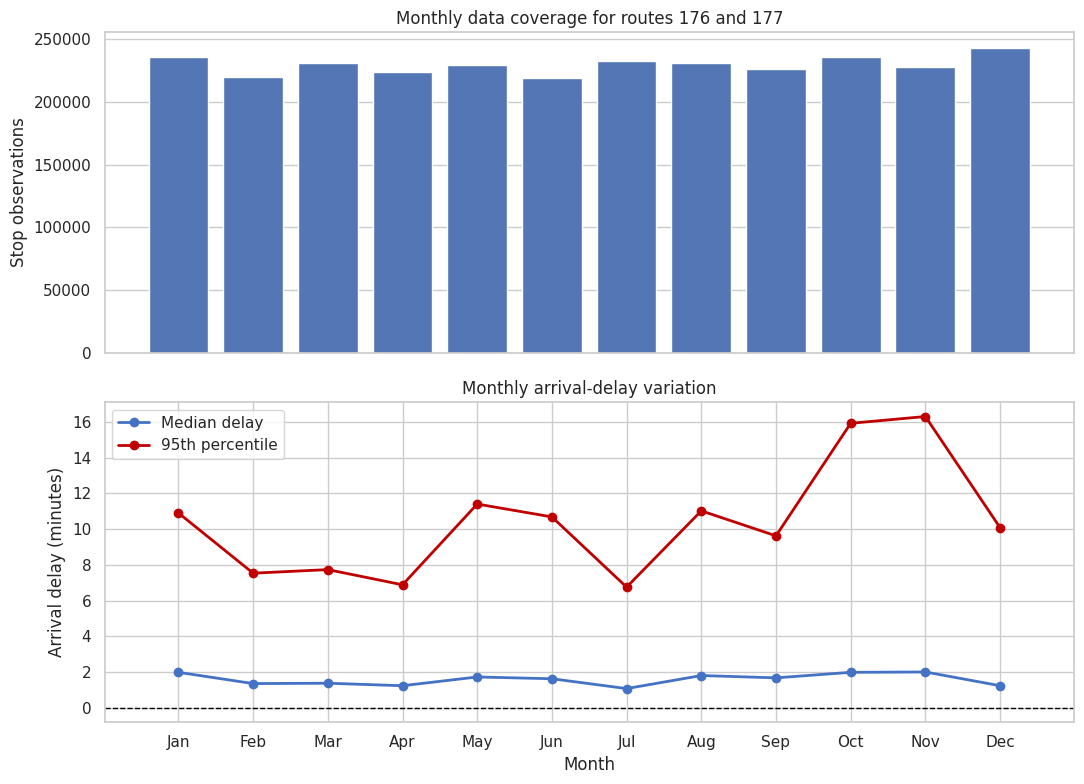

Figure saved to: /content/drive/MyDrive/AH2179_Final_Project_Bus_176_177/figures/figure_monthly_coverage_and_delay.png


In [12]:
# Calculate monthly descriptive statistics

monthly_summary = (
    full_2024
    .groupby("month")
    .agg(
        observations=("LineNumber", "size"),
        available_arrival_delays=(
            "observed_arrival_delay",
            "count"
        ),
        mean_delay_min=(
            "arrival_delay_min",
            "mean"
        ),
        median_delay_min=(
            "arrival_delay_min",
            "median"
        ),
        p95_delay_min=(
            "arrival_delay_min",
            lambda values: values.quantile(0.95)
        )
    )
    .reset_index()
)

monthly_summary["month_name"] = (
    monthly_summary["month"]
    .map(lambda month: calendar.month_abbr[month])
)

for column in [
    "mean_delay_min",
    "median_delay_min",
    "p95_delay_min"
]:
    monthly_summary[column] = (
        monthly_summary[column].round(2)
    )

print("MONTHLY SUMMARY")
display(monthly_summary)

# Create two related monthly figures
fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 8),
    sharex=True
)

# Monthly data coverage
sns.barplot(
    data=monthly_summary,
    x="month_name",
    y="observations",
    color="#4472C4",
    ax=axes[0]
)

axes[0].set_title(
    "Monthly data coverage for routes 176 and 177"
)
axes[0].set_xlabel("")
axes[0].set_ylabel("Stop observations")

# Typical and disrupted delay conditions
axes[1].plot(
    monthly_summary["month_name"],
    monthly_summary["median_delay_min"],
    marker="o",
    linewidth=2,
    color="#4472C4",
    label="Median delay"
)

axes[1].plot(
    monthly_summary["month_name"],
    monthly_summary["p95_delay_min"],
    marker="o",
    linewidth=2,
    color="#C00000",
    label="95th percentile"
)

axes[1].axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

axes[1].set_title(
    "Monthly arrival-delay variation"
)
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Arrival delay (minutes)")
axes[1].legend()

plt.tight_layout()

monthly_figure = (
    FIGURES_DIR /
    "figure_monthly_coverage_and_delay.png"
)

plt.savefig(
    monthly_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {monthly_figure}")

### Interpretation of monthly variation

Monthly observation volumes are relatively stable, indicating consistent
coverage throughout 2024. However, delay conditions vary substantially.
October and November show the highest mean and 95th-percentile delays, while
July shows the lowest values.

The monthly medians vary less than the means and 95th percentiles. This
indicates that seasonal differences are primarily driven by severe disruption
events rather than by a uniform deterioration of all services. Consequently,
model performance should be evaluated separately across months and under both
normal and disrupted operating conditions.

## 6. Full-year quality and dwell-time assessment

Before defining the final cleaning rules, the full-year dataset is examined
for matching failures, duplicated trip-stop observations, missing arrival
information and implausible dwell times. Dwell time represents the time
between arrival at and departure from a stop and is particularly relevant to
the operational motivation concerning boarding efficiency.

MATCHING FLAGS FOR THE COMPLETE YEAR

tripupdates_and_gtfs_not_merged_within_service_id:


,value,observations
0,f,2758280



tripupdates_not_merged_with_stoptimes_or_trip:


,value,observations
0,f,2758280



DUPLICATE ASSESSMENT
Exact duplicate rows: 0
Rows with duplicated trip-stop keys: 0

ARRIVAL-DATA AVAILABILITY


,month,observations,available_arrivals,missing_percent,month_name
0,1,235684,234498,0.50,Jan
1,2,219840,209597,4.66,Feb
2,3,231422,224998,2.78,Mar
3,4,224131,221922,0.99,Apr
4,5,229912,224756,2.24,May
5,6,219184,217159,0.92,Jun
6,7,232786,231689,0.47,Jul
7,8,231367,230367,0.43,Aug
8,9,226278,225515,0.34,Sep
9,10,236349,234463,0.80,Oct



DWELL-TIME DISTRIBUTIONS IN SECONDS


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
observed_dwell_sec,2715689.0,18.66,44.21,0.0,0.0,0.0,0.0,10.0,19.0,77.0,194.0,8540.0
scheduled_dwell_sec,2758280.0,0.52,6.43,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,120.0
excess_dwell_sec,2715689.0,18.16,43.35,-120.0,0.0,0.0,0.0,10.0,19.0,73.0,191.0,8540.0



POTENTIALLY IMPLAUSIBLE DWELL TIMES
Negative observed dwell times: 0
Observed dwell times above 10 minutes: 1,218


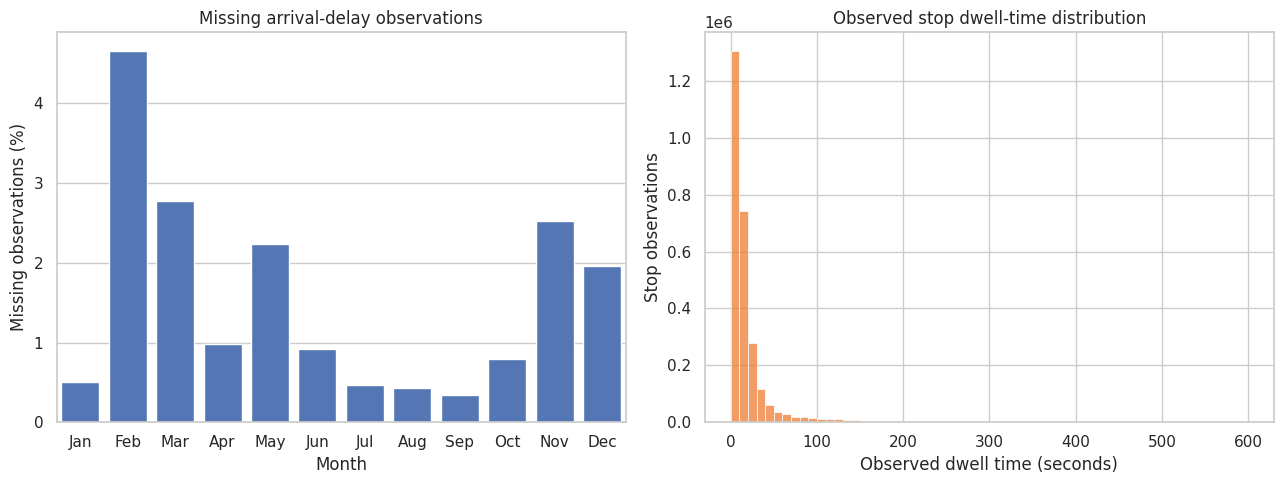

Figure saved to: /content/drive/MyDrive/AH2179_Final_Project_Bus_176_177/figures/figure_full_year_quality_and_dwell.png


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. Matching quality
# ---------------------------------------------------------

quality_flags = [
    "tripupdates_and_gtfs_not_merged_within_service_id",
    "tripupdates_not_merged_with_stoptimes_or_trip"
]

print("MATCHING FLAGS FOR THE COMPLETE YEAR")

for column in quality_flags:
    print(f"\n{column}:")
    display(
        full_2024[column]
        .value_counts(dropna=False)
        .rename_axis("value")
        .reset_index(name="observations")
    )

# ---------------------------------------------------------
# 2. Duplicate trip-stop observations
# ---------------------------------------------------------

trip_stop_key = [
    "date",
    "route_id",
    "trip_id",
    "direction_id",
    "stop_sequence",
    "observed_stop_id"
]

exact_duplicates = full_2024.duplicated().sum()

key_duplicates = full_2024.duplicated(
    subset=trip_stop_key,
    keep=False
).sum()

print("\nDUPLICATE ASSESSMENT")
print(f"Exact duplicate rows: {exact_duplicates:,}")
print(
    "Rows with duplicated trip-stop keys:",
    f"{key_duplicates:,}"
)

# ---------------------------------------------------------
# 3. Arrival-data availability by month
# ---------------------------------------------------------

monthly_availability = (
    full_2024
    .groupby("month")
    .agg(
        observations=("LineNumber", "size"),
        available_arrivals=(
            "observed_arrival_delay",
            "count"
        )
    )
    .reset_index()
)

monthly_availability["missing_percent"] = (
    100
    * (
        1
        - monthly_availability["available_arrivals"]
        / monthly_availability["observations"]
    )
)

monthly_availability["month_name"] = (
    monthly_availability["month"]
    .map(lambda month: calendar.month_abbr[month])
)

print("\nARRIVAL-DATA AVAILABILITY")
display(monthly_availability.round(2))

# ---------------------------------------------------------
# 4. Dwell-time variables
# ---------------------------------------------------------

full_2024["observed_dwell_sec"] = (
    full_2024["observed_departure_time_sfm"]
    - full_2024["observed_arrival_time_sfm"]
)

full_2024["scheduled_dwell_sec"] = (
    full_2024["scheduled_departure_time_sfm"]
    - full_2024["scheduled_arrival_time_sfm"]
)

full_2024["excess_dwell_sec"] = (
    full_2024["observed_dwell_sec"]
    - full_2024["scheduled_dwell_sec"]
)

dwell_columns = [
    "observed_dwell_sec",
    "scheduled_dwell_sec",
    "excess_dwell_sec"
]

print("\nDWELL-TIME DISTRIBUTIONS IN SECONDS")

display(
    full_2024[dwell_columns]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
    .T
    .round(2)
)

print("\nPOTENTIALLY IMPLAUSIBLE DWELL TIMES")
print(
    "Negative observed dwell times:",
    f"{(full_2024['observed_dwell_sec'] < 0).sum():,}"
)
print(
    "Observed dwell times above 10 minutes:",
    f"{(full_2024['observed_dwell_sec'] > 600).sum():,}"
)

# ---------------------------------------------------------
# 5. Data-quality figures
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

# Monthly missing-arrival rate
sns.barplot(
    data=monthly_availability,
    x="month_name",
    y="missing_percent",
    color="#4472C4",
    ax=axes[0]
)

axes[0].set_title("Missing arrival-delay observations")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Missing observations (%)")

# Display the main dwell-time distribution
dwell_for_plot = full_2024[
    full_2024["observed_dwell_sec"].between(0, 600)
].copy()

sns.histplot(
    data=dwell_for_plot,
    x="observed_dwell_sec",
    bins=60,
    color="#ED7D31",
    edgecolor=None,
    ax=axes[1]
)

axes[1].set_title("Observed stop dwell-time distribution")
axes[1].set_xlabel("Observed dwell time (seconds)")
axes[1].set_ylabel("Stop observations")

plt.tight_layout()

quality_figure = (
    FIGURES_DIR /
    "figure_full_year_quality_and_dwell.png"
)

plt.savefig(
    quality_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {quality_figure}")

### Full-year quality findings

All observations were successfully matched between GTFS and GTFS-Realtime,
and no duplicate trip-stop records were identified. Missing arrival
observations vary by month and are most frequent in February, but remain
limited overall.

Observed dwell times are strongly right-skewed. The median is 10 seconds and
the 99th percentile is 194 seconds, while 1,218 observations exceed ten
minutes. The original observations are preserved for diagnostic analysis.
However, dwell times above ten minutes are excluded from the primary
prediction dataset because they may represent terminal layovers, unusual
disruptions or measurement errors rather than ordinary stop operations.

## 7. Construction of the next-stop prediction dataset

The prediction unit is a bus departure from a current stop. The target
variable is the observed arrival delay at the next recorded stop. Information
known after departure from the current stop, including current delay and dwell
time, can therefore be used without introducing future-data leakage.

Rows without an observed next-stop arrival delay are excluded because the
target variable cannot be imputed. Dwell times above ten minutes are excluded
from the primary model dataset but retained in the original dataset for later
robustness diagnostics.

In [14]:
# ---------------------------------------------------------
# Construct the next-stop prediction target
# ---------------------------------------------------------

group_columns = [
    "date",
    "route_id",
    "trip_id",
    "direction_id"
]

# Ensure correct chronological ordering within every trip
full_2024 = full_2024.sort_values(
    group_columns + ["stop_sequence"]
).reset_index(drop=True)

trip_groups = full_2024.groupby(
    group_columns,
    sort=False
)

# Variables describing the next recorded stop
full_2024["next_arrival_delay_sec"] = (
    trip_groups["observed_arrival_delay"].shift(-1)
)

full_2024["next_stop_id"] = (
    trip_groups["observed_stop_id"].shift(-1)
)

full_2024["next_stop_sequence"] = (
    trip_groups["stop_sequence"].shift(-1)
)

full_2024["next_segment_distance_m"] = (
    trip_groups["dist_traveled"].shift(-1)
)

full_2024["next_scheduled_arrival_sfm"] = (
    trip_groups["scheduled_arrival_time_sfm"].shift(-1)
)

# Verify that the shifted observation occurs later in the trip
valid_next_stop = (
    full_2024["next_stop_sequence"]
    > full_2024["stop_sequence"]
)

# ---------------------------------------------------------
# Define transparent cleaning conditions
# ---------------------------------------------------------

conditions = pd.DataFrame(
    {
        "valid_next_stop": valid_next_stop,
        "current_arrival_available":
            full_2024["observed_arrival_delay"].notna(),
        "current_departure_available":
            full_2024["observed_departure_delay"].notna(),
        "next_arrival_available":
            full_2024["next_arrival_delay_sec"].notna(),
        "current_dwell_available":
            full_2024["observed_dwell_sec"].notna(),
        "plausible_current_dwell":
            full_2024["observed_dwell_sec"].between(
                0,
                600,
                inclusive="both"
            ),
        "next_distance_available":
            full_2024["next_segment_distance_m"].notna()
    }
)

# Sequential cleaning summary
cleaning_steps = []
current_mask = pd.Series(
    True,
    index=full_2024.index
)

cleaning_steps.append({
    "step": "All route observations",
    "remaining_rows": int(current_mask.sum())
})

for column in conditions.columns:
    current_mask &= conditions[column]

    cleaning_steps.append({
        "step": column,
        "remaining_rows": int(current_mask.sum())
    })

cleaning_summary = pd.DataFrame(cleaning_steps)

# Create the primary modelling dataset
model_data = full_2024.loc[
    current_mask
].copy()

# Target expressed in minutes
model_data["target_next_arrival_delay_min"] = (
    model_data["next_arrival_delay_sec"] / 60
)

# Flag severe delays without removing them
model_data["severe_next_stop_delay"] = (
    model_data["target_next_arrival_delay_min"] > 30
).astype(int)

# Save the modelling dataset
model_data_file = (
    PROCESSED_DIR /
    "model_dataset_176_177_2024.parquet"
)

model_data.to_parquet(
    model_data_file,
    index=False
)

# ---------------------------------------------------------
# Report the result
# ---------------------------------------------------------

retained_percent = (
    100 * len(model_data) / len(full_2024)
)

print("CLEANING SUMMARY")
display(cleaning_summary)

print("\nFINAL PREDICTION DATASET")
print(f"Rows: {len(model_data):,}")
print(f"Retained: {retained_percent:.2f}%")
print(
    "Severe next-stop delays above 30 minutes:",
    f"{model_data['severe_next_stop_delay'].sum():,}"
)
print(f"Saved to: {model_data_file}")

print("\nTARGET DISTRIBUTION IN MINUTES")

display(
    model_data["target_next_arrival_delay_min"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
    .to_frame("value")
    .round(2)
)

print("\nOBSERVATIONS BY ROUTE")

display(
    model_data["LineNumber"]
    .value_counts()
    .rename_axis("route")
    .reset_index(name="observations")
)

CLEANING SUMMARY


,step,remaining_rows
0,All route observations,2758280
1,valid_next_stop,2686659
2,current_arrival_available,2644892
3,current_departure_available,2644795
4,next_arrival_available,2644777
5,current_dwell_available,2644777
6,plausible_current_dwell,2643576
7,next_distance_available,2643576



FINAL PREDICTION DATASET
Rows: 2,643,576
Retained: 95.84%
Severe next-stop delays above 30 minutes: 18,897
Saved to: /content/drive/MyDrive/AH2179_Final_Project_Bus_176_177/data/processed/model_dataset_176_177_2024.parquet

TARGET DISTRIBUTION IN MINUTES


,value
count,2643576.00
mean,2.78
std,6.28
min,-25.73
1%,-4.62
5%,-2.23
25%,0.20
50%,1.62
75%,3.77
95%,10.32



OBSERVATIONS BY ROUTE


,route,observations
0,176,1448682
1,177,1194894


## 8. Stop-level and spatial descriptive analysis

Static GTFS stop information is linked to the prediction dataset to provide
stop names and geographical coordinates. Delay accumulation at a stop is
measured as the difference between observed departure delay and observed
arrival delay. A positive value indicates that the bus lost time while
serving the stop, whereas a negative value indicates partial delay recovery.

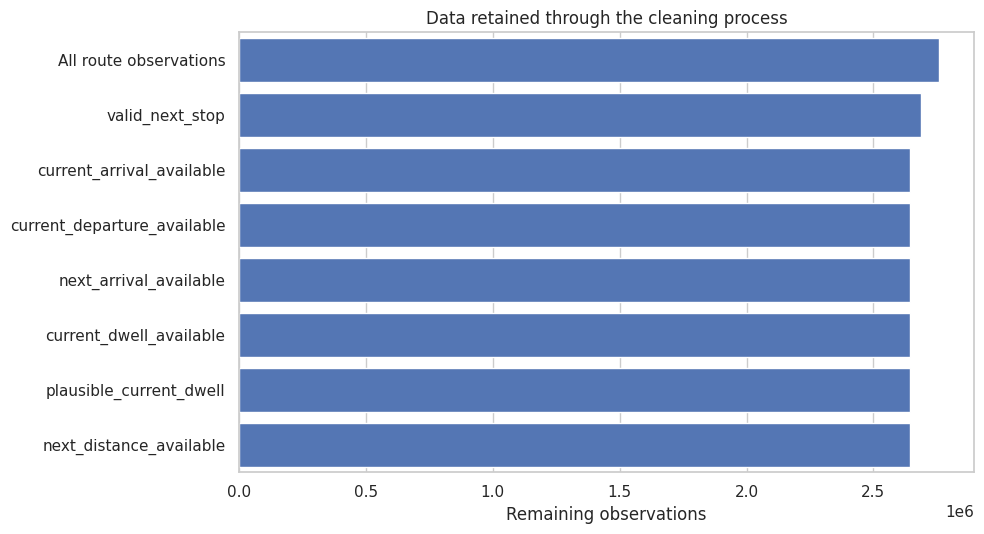

Figure saved to: /content/drive/MyDrive/AH2179_Final_Project_Bus_176_177/figures/figure_prediction_data_cleaning.png


In [15]:
plt.figure(figsize=(10, 5.5))

plot_summary = cleaning_summary.copy()

plot_summary["removed_rows"] = (
    len(full_2024)
    - plot_summary["remaining_rows"]
)

sns.barplot(
    data=plot_summary,
    x="remaining_rows",
    y="step",
    color="#4472C4"
)

plt.xlabel("Remaining observations")
plt.ylabel("")
plt.title("Data retained through the cleaning process")
plt.xlim(0, len(full_2024) * 1.05)
plt.tight_layout()

cleaning_figure = (
    FIGURES_DIR /
    "figure_prediction_data_cleaning.png"
)

plt.savefig(
    cleaning_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {cleaning_figure}")

### Interpretation of the cleaning process

The largest reduction occurs when terminal observations without a subsequent
stop are removed. Additional reductions result mainly from missing real-time
arrival or departure information. Only a small number of observations are
excluded by the ten-minute dwell-time threshold. Overall, 95.84% of the
original observations are retained, indicating that the cleaning procedure
preserves most of the available operational information.

In [16]:
# ---------------------------------------------------------
# Load static GTFS stop information
# ---------------------------------------------------------

stops_file = RAW_DIR / "stops.csv"

# Automatic separator detection
stops = pd.read_csv(
    stops_file,
    sep=None,
    engine="python",
    dtype="string"
)

print("Columns in stops.csv:")
print(stops.columns.tolist())
print(f"Number of stop records: {len(stops):,}")

required_stop_columns = [
    "stop_id",
    "stop_name",
    "stop_lat",
    "stop_lon"
]

missing_stop_columns = [
    column
    for column in required_stop_columns
    if column not in stops.columns
]

if missing_stop_columns:
    raise ValueError(
        "Missing required stop columns: "
        f"{missing_stop_columns}"
    )

# ---------------------------------------------------------
# Standardise identifiers before joining
# ---------------------------------------------------------

def normalize_identifier(series):
    """Convert numeric GTFS identifiers to consistent strings."""

    return (
        pd.to_numeric(series, errors="coerce")
        .astype("Int64")
        .astype("string")
    )

stops["stop_id_key"] = normalize_identifier(
    stops["stop_id"]
)

model_data["current_stop_key"] = normalize_identifier(
    model_data["observed_stop_id"]
)

model_data["next_stop_key"] = normalize_identifier(
    model_data["next_stop_id"]
)

# Coordinates must be numeric for plotting
stops["stop_lat"] = pd.to_numeric(
    stops["stop_lat"],
    errors="coerce"
)

stops["stop_lon"] = pd.to_numeric(
    stops["stop_lon"],
    errors="coerce"
)

# ---------------------------------------------------------
# Add current-stop information
# ---------------------------------------------------------

current_stop_lookup = (
    stops[
        [
            "stop_id_key",
            "stop_name",
            "stop_lat",
            "stop_lon"
        ]
    ]
    .drop_duplicates("stop_id_key")
    .rename(
        columns={
            "stop_id_key": "current_stop_key",
            "stop_name": "current_stop_name",
            "stop_lat": "current_stop_lat",
            "stop_lon": "current_stop_lon"
        }
    )
)

model_data = model_data.merge(
    current_stop_lookup,
    on="current_stop_key",
    how="left",
    validate="many_to_one"
)

# ---------------------------------------------------------
# Add next-stop information
# ---------------------------------------------------------

next_stop_lookup = (
    stops[
        [
            "stop_id_key",
            "stop_name",
            "stop_lat",
            "stop_lon"
        ]
    ]
    .drop_duplicates("stop_id_key")
    .rename(
        columns={
            "stop_id_key": "next_stop_key",
            "stop_name": "next_stop_name",
            "stop_lat": "next_stop_lat",
            "stop_lon": "next_stop_lon"
        }
    )
)

model_data = model_data.merge(
    next_stop_lookup,
    on="next_stop_key",
    how="left",
    validate="many_to_one"
)

# ---------------------------------------------------------
# Calculate delay accumulation
# ---------------------------------------------------------

# Delay added while serving the current stop
model_data["stop_delay_change_sec"] = (
    model_data["observed_departure_delay"]
    - model_data["observed_arrival_delay"]
)

# Delay gained or recovered while travelling to the next stop
model_data["segment_delay_change_sec"] = (
    model_data["next_arrival_delay_sec"]
    - model_data["observed_departure_delay"]
)

current_match_rate = (
    model_data["current_stop_name"].notna().mean() * 100
)

next_match_rate = (
    model_data["next_stop_name"].notna().mean() * 100
)

print("\nSTOP MATCHING")
print(f"Current-stop match rate: {current_match_rate:.2f}%")
print(f"Next-stop match rate: {next_match_rate:.2f}%")

# Save enriched modelling data
enriched_model_file = (
    PROCESSED_DIR /
    "model_dataset_176_177_2024_enriched.parquet"
)

model_data.to_parquet(
    enriched_model_file,
    index=False
)

print(f"Saved to: {enriched_model_file}")

Columns in stops.csv:
['stop_id', 'stop_name', 'stop_lat', 'stop_lon', 'location_type', 'parent_station', 'platform_code']
Number of stop records: 21,661

STOP MATCHING
Current-stop match rate: 100.00%
Next-stop match rate: 49.55%
Saved to: /content/drive/MyDrive/AH2179_Final_Project_Bus_176_177/data/processed/model_dataset_176_177_2024_enriched.parquet


### Correction of next-stop identifiers

The initial next-stop matching rate was only 49.55%. This was caused by
precision loss when long numeric GTFS stop identifiers were shifted in a
column containing missing values. The identifiers were therefore reconstructed
as strings before applying the next-stop shift. This correction affects only
the stop identifier and associated stop metadata; the delay target remains
unchanged.

TOP DELAY-ACCUMULATION STOPS


,LineNumber,direction_id,current_stop_name,observations,mean_delay_added_sec,median_delay_added_sec,mean_dwell_sec,p95_dwell_sec
145,177,1,Tappström,17805,87.18,82.0,87.18,196.00
112,177,0,Tappström,17595,85.91,73.0,85.91,223.00
2,176,0,Brommaplan,34684,84.21,45.0,84.21,282.00
83,177,0,Brommaplan,34809,82.86,41.0,83.09,282.00
35,176,0,Tappström,34766,59.64,30.0,59.64,177.00
76,176,1,Tappström,34426,58.86,33.0,58.86,163.00
22,176,0,Mörby station,16586,54.49,18.0,94.35,291.00
101,177,0,Mörby station,16716,53.87,17.0,94.09,290.00
118,177,1,Brommaplan,35743,53.70,33.0,53.70,181.00
43,176,1,Brommaplan,34781,53.55,34.0,53.55,183.00


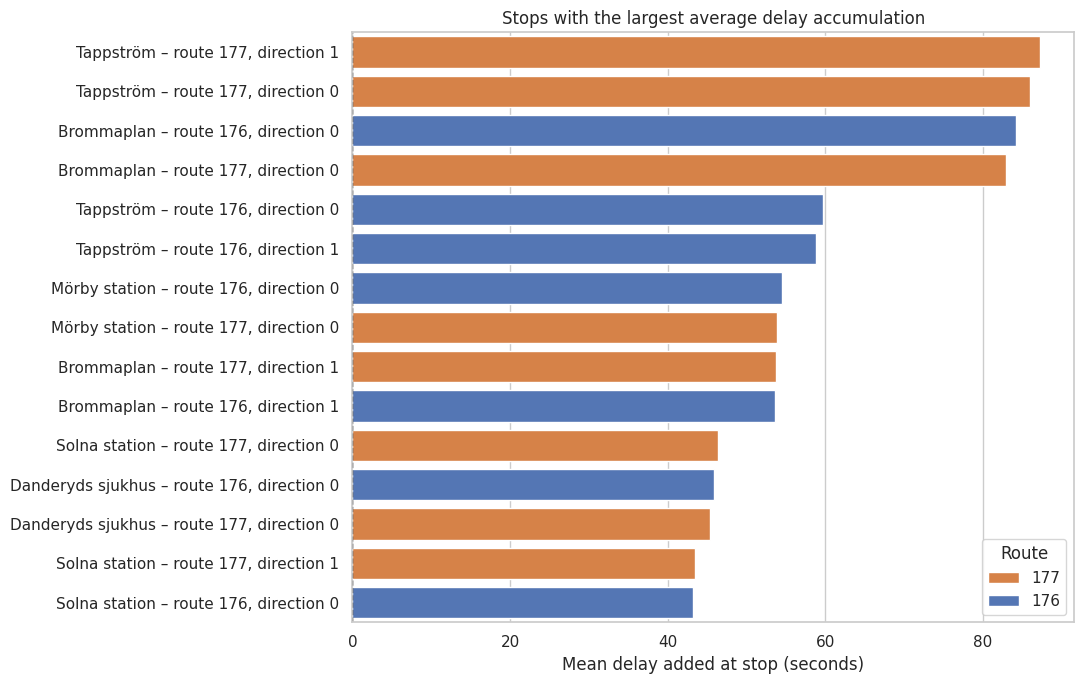

Figure saved to: /content/drive/MyDrive/AH2179_Final_Project_Bus_176_177/figures/figure_stop_delay_accumulation.png


In [17]:
# ---------------------------------------------------------
# Identify stop-level delay-accumulation hotspots
# ---------------------------------------------------------

stop_summary = (
    model_data
    .dropna(subset=["current_stop_name"])
    .groupby(
        [
            "LineNumber",
            "direction_id",
            "current_stop_name"
        ]
    )
    .agg(
        observations=(
            "stop_delay_change_sec",
            "count"
        ),
        mean_delay_added_sec=(
            "stop_delay_change_sec",
            "mean"
        ),
        median_delay_added_sec=(
            "stop_delay_change_sec",
            "median"
        ),
        mean_dwell_sec=(
            "observed_dwell_sec",
            "mean"
        ),
        p95_dwell_sec=(
            "observed_dwell_sec",
            lambda values: values.quantile(0.95)
        )
    )
    .reset_index()
)

# Require sufficient observations for stable estimates
stop_summary_reliable = stop_summary[
    stop_summary["observations"] >= 1000
].copy()

top_stops = (
    stop_summary_reliable
    .sort_values(
        "mean_delay_added_sec",
        ascending=False
    )
    .head(15)
    .copy()
)

top_stops["stop_label"] = (
    top_stops["current_stop_name"]
    + " – route "
    + top_stops["LineNumber"].astype(str)
    + ", direction "
    + top_stops["direction_id"].astype(str)
)

print("TOP DELAY-ACCUMULATION STOPS")
display(
    top_stops[
        [
            "LineNumber",
            "direction_id",
            "current_stop_name",
            "observations",
            "mean_delay_added_sec",
            "median_delay_added_sec",
            "mean_dwell_sec",
            "p95_dwell_sec"
        ]
    ].round(2)
)

# ---------------------------------------------------------
# Figure: stop-level delay accumulation
# ---------------------------------------------------------

plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_stops,
    x="mean_delay_added_sec",
    y="stop_label",
    hue="LineNumber",
    dodge=False,
    palette={
        "176": "#4472C4",
        "177": "#ED7D31"
    }
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.xlabel("Mean delay added at stop (seconds)")
plt.ylabel("")
plt.title(
    "Stops with the largest average delay accumulation"
)
plt.legend(title="Route")
plt.tight_layout()

stop_figure = (
    FIGURES_DIR /
    "figure_stop_delay_accumulation.png"
)

plt.savefig(
    stop_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {stop_figure}")

## 8. Stop-level and spatial descriptive analysis

### Interpretation of stop-level delay accumulation

The largest average increases in delay occur primarily at major interchange
stops. Tappström and Brommaplan show particularly large delay accumulation,
with several route-direction combinations adding approximately one minute or
more during an average stop visit. Mörby station, Solna station and Danderyds
sjukhus also appear among the main hotspots.

These findings closely correspond to the locations highlighted by SL when
all-door boarding was introduced on routes 176 and 177 in November 2025:
Tappström, Brommaplan, Solna station and Danderyds sjukhus. This correspondence
supports the operational relevance of the 2024 analysis. However, the results
do not estimate the causal effect of all-door boarding because the dataset
covers the pre-implementation period only.

## 9. Temporal delay patterns

Arrival delays are examined by scheduled hour and day of the week. Both the
median and 95th percentile are reported. The median represents typical
operations, while the 95th percentile illustrates disrupted conditions and
the reliability risk experienced by passengers.

HOURLY DELAY SUMMARY


,LineNumber,scheduled_hour,observations,median_delay_min,p95_delay_min
0,176,0,19000,1.02,6.65
1,176,4,4489,1.72,4.88
2,176,5,26386,1.28,6.05
3,176,6,63100,1.28,6.43
4,176,7,71726,1.25,6.98
5,176,8,76832,1.67,8.20
6,176,9,81519,1.55,7.98
7,176,10,86148,1.88,8.55
8,176,11,89603,1.92,8.88
9,176,12,90987,2.23,10.35



WEEKDAY DELAY SUMMARY


,LineNumber,weekday,observations,median_delay_min,p95_delay_min,weekday_name
0,176,0,222244,1.50,8.53,Mon
1,176,1,222065,1.93,11.70,Tue
2,176,2,218212,1.90,11.10,Wed
3,176,3,214535,1.85,10.67,Thu
4,176,4,217075,1.60,9.25,Fri
5,176,5,177512,2.38,12.98,Sat
6,176,6,177039,1.63,9.92,Sun
7,177,0,182091,1.07,7.60,Mon
8,177,1,182122,1.38,10.90,Tue
9,177,2,179019,1.33,9.92,Wed


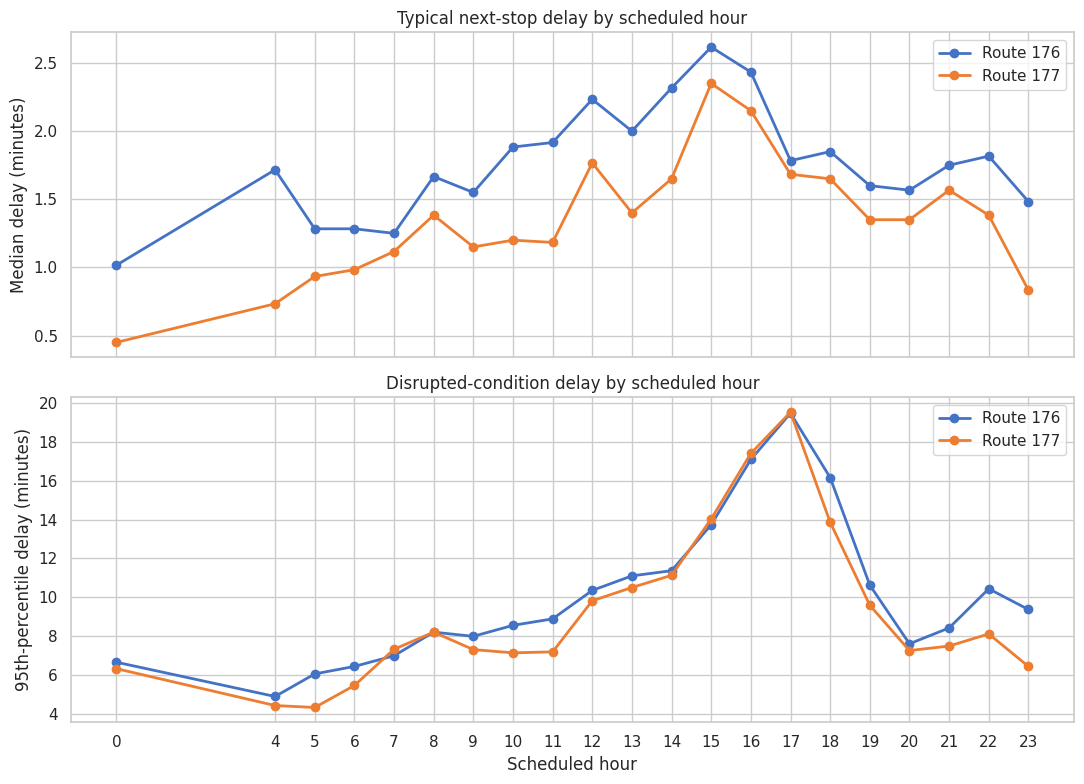

Figure saved to: /content/drive/MyDrive/AH2179_Final_Project_Bus_176_177/figures/figure_hourly_delay_patterns.png


In [18]:
# ---------------------------------------------------------
# Hourly delay statistics
# ---------------------------------------------------------

hourly_summary = (
    model_data
    .groupby(
        ["LineNumber", "scheduled_hour"]
    )
    .agg(
        observations=(
            "target_next_arrival_delay_min",
            "size"
        ),
        median_delay_min=(
            "target_next_arrival_delay_min",
            "median"
        ),
        p95_delay_min=(
            "target_next_arrival_delay_min",
            lambda values: values.quantile(0.95)
        )
    )
    .reset_index()
)

# Exclude hours with limited service for stable comparisons
hourly_reliable = hourly_summary[
    hourly_summary["observations"] >= 1000
].copy()

print("HOURLY DELAY SUMMARY")
display(
    hourly_reliable.round(2)
)

# ---------------------------------------------------------
# Weekday delay statistics
# ---------------------------------------------------------

weekday_names = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun"
}

weekday_summary = (
    model_data
    .groupby(
        ["LineNumber", "weekday"]
    )
    .agg(
        observations=(
            "target_next_arrival_delay_min",
            "size"
        ),
        median_delay_min=(
            "target_next_arrival_delay_min",
            "median"
        ),
        p95_delay_min=(
            "target_next_arrival_delay_min",
            lambda values: values.quantile(0.95)
        )
    )
    .reset_index()
)

weekday_summary["weekday_name"] = (
    weekday_summary["weekday"]
    .map(weekday_names)
)

print("\nWEEKDAY DELAY SUMMARY")
display(
    weekday_summary.round(2)
)

# ---------------------------------------------------------
# Figure: hourly median and disrupted-condition delays
# ---------------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 8),
    sharex=True
)

route_colors = {
    "176": "#4472C4",
    "177": "#ED7D31"
}

for route in ["176", "177"]:

    route_data = hourly_reliable[
        hourly_reliable["LineNumber"] == route
    ]

    axes[0].plot(
        route_data["scheduled_hour"],
        route_data["median_delay_min"],
        marker="o",
        linewidth=2,
        color=route_colors[route],
        label=f"Route {route}"
    )

    axes[1].plot(
        route_data["scheduled_hour"],
        route_data["p95_delay_min"],
        marker="o",
        linewidth=2,
        color=route_colors[route],
        label=f"Route {route}"
    )

axes[0].set_title("Typical next-stop delay by scheduled hour")
axes[0].set_ylabel("Median delay (minutes)")
axes[0].legend()

axes[1].set_title("Disrupted-condition delay by scheduled hour")
axes[1].set_xlabel("Scheduled hour")
axes[1].set_ylabel("95th-percentile delay (minutes)")
axes[1].legend()

axes[1].set_xticks(
    sorted(hourly_reliable["scheduled_hour"].unique())
)

plt.tight_layout()

hourly_figure = (
    FIGURES_DIR /
    "figure_hourly_delay_patterns.png"
)

plt.savefig(
    hourly_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {hourly_figure}")

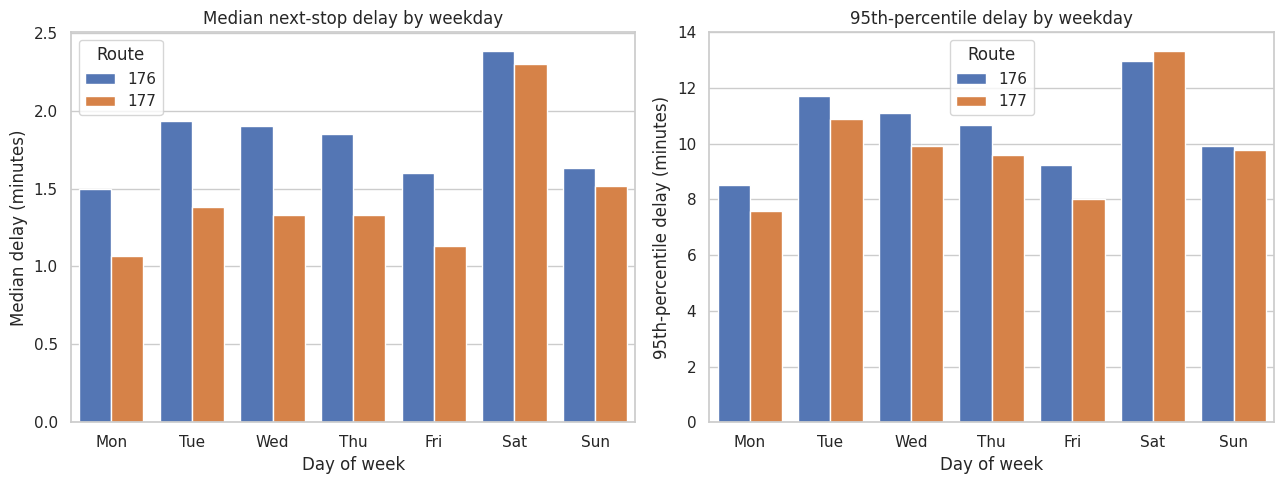

Figure saved to: /content/drive/MyDrive/AH2179_Final_Project_Bus_176_177/figures/figure_weekday_delay_patterns.png


In [19]:
# ---------------------------------------------------------
# Figure: weekday comparison
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

sns.barplot(
    data=weekday_summary,
    x="weekday_name",
    y="median_delay_min",
    hue="LineNumber",
    order=[
        "Mon",
        "Tue",
        "Wed",
        "Thu",
        "Fri",
        "Sat",
        "Sun"
    ],
    palette=route_colors,
    ax=axes[0]
)

axes[0].set_title("Median next-stop delay by weekday")
axes[0].set_xlabel("Day of week")
axes[0].set_ylabel("Median delay (minutes)")
axes[0].legend(title="Route")

sns.barplot(
    data=weekday_summary,
    x="weekday_name",
    y="p95_delay_min",
    hue="LineNumber",
    order=[
        "Mon",
        "Tue",
        "Wed",
        "Thu",
        "Fri",
        "Sat",
        "Sun"
    ],
    palette=route_colors,
    ax=axes[1]
)

axes[1].set_title("95th-percentile delay by weekday")
axes[1].set_xlabel("Day of week")
axes[1].set_ylabel("95th-percentile delay (minutes)")
axes[1].legend(title="Route")

plt.tight_layout()

weekday_figure = (
    FIGURES_DIR /
    "figure_weekday_delay_patterns.png"
)

plt.savefig(
    weekday_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {weekday_figure}")

In [20]:
# ---------------------------------------------------------
# Correct next-stop identifiers without numeric precision loss
# ---------------------------------------------------------

group_columns = [
    "date",
    "route_id",
    "trip_id",
    "direction_id"
]

record_key = group_columns + ["stop_sequence"]

# Convert the current-stop IDs to exact strings before shifting
full_2024["current_stop_key_exact"] = (
    pd.to_numeric(
        full_2024["observed_stop_id"],
        errors="coerce"
    )
    .astype("Int64")
    .astype("string")
)

# Shift string identifiers, avoiding float conversion
full_2024["next_stop_key_exact"] = (
    full_2024
    .groupby(
        group_columns,
        sort=False
    )["current_stop_key_exact"]
    .shift(-1)
)

# Create an exact current-record to next-stop lookup
exact_next_stop_lookup = (
    full_2024[
        record_key + ["next_stop_key_exact"]
    ]
    .drop_duplicates(record_key)
)

# Remove the incorrectly matched next-stop information
columns_to_remove = [
    "next_stop_key",
    "next_stop_name",
    "next_stop_lat",
    "next_stop_lon"
]

model_data = model_data.drop(
    columns=[
        column
        for column in columns_to_remove
        if column in model_data.columns
    ]
)

# Attach the corrected next-stop identifier
model_data = model_data.merge(
    exact_next_stop_lookup,
    on=record_key,
    how="left",
    validate="one_to_one"
)

model_data = model_data.rename(
    columns={
        "next_stop_key_exact": "next_stop_key"
    }
)

# Replace the imprecise numeric next-stop identifier
model_data["next_stop_id"] = model_data["next_stop_key"]

# Attach corrected next-stop names and coordinates
model_data = model_data.merge(
    next_stop_lookup,
    on="next_stop_key",
    how="left",
    validate="many_to_one"
)

# Verify matching rates
current_match_rate = (
    model_data["current_stop_name"].notna().mean()
    * 100
)

next_match_rate = (
    model_data["next_stop_name"].notna().mean()
    * 100
)

print("CORRECTED STOP MATCHING")
print(
    f"Current-stop match rate: "
    f"{current_match_rate:.2f}%"
)
print(
    f"Next-stop match rate: "
    f"{next_match_rate:.2f}%"
)

print("\nExample current-to-next stop pairs:")

display(
    model_data[
        [
            "LineNumber",
            "direction_id",
            "current_stop_name",
            "next_stop_name"
        ]
    ]
    .drop_duplicates()
    .head(20)
)

# Overwrite the enriched dataset with corrected identifiers
model_data.to_parquet(
    enriched_model_file,
    index=False
)

print(
    "\nCorrected enriched dataset saved to:",
    enriched_model_file
)

CORRECTED STOP MATCHING
Current-stop match rate: 100.00%
Next-stop match rate: 100.00%

Example current-to-next stop pairs:


,LineNumber,direction_id,current_stop_name,next_stop_name
0,176,1,Solbacka,Fårhagen
1,176,1,Fårhagen,Fårhagsplan
2,176,1,Fårhagsplan,Stenhamra centrum
3,176,1,Stenhamra centrum,Eknäs
4,176,1,Eknäs,Västeräng
5,176,1,Västeräng,Rosenborg
6,176,1,Rosenborg,Törnby
7,176,1,Törnby,Svanhagen
8,176,1,Svanhagen,Ekeberga
9,176,1,Ekeberga,Mörbyvägen



Corrected enriched dataset saved to: /content/drive/MyDrive/AH2179_Final_Project_Bus_176_177/data/processed/model_dataset_176_177_2024_enriched.parquet


The corrected identifier procedure achieved a 100% matching rate for both
current and next stops. Inspection of consecutive stop pairs confirmed a
logical route sequence. The corrected stop identifiers and geographical
attributes are therefore used in all subsequent spatial analyses and model
features.


### Spatial distribution of stop-level delay accumulation

The following figure presents the geographical alignment of each route and
direction. Stops are coloured according to the average delay added during the
stop visit. Darker colours indicate locations where buses tend to accumulate
more delay.

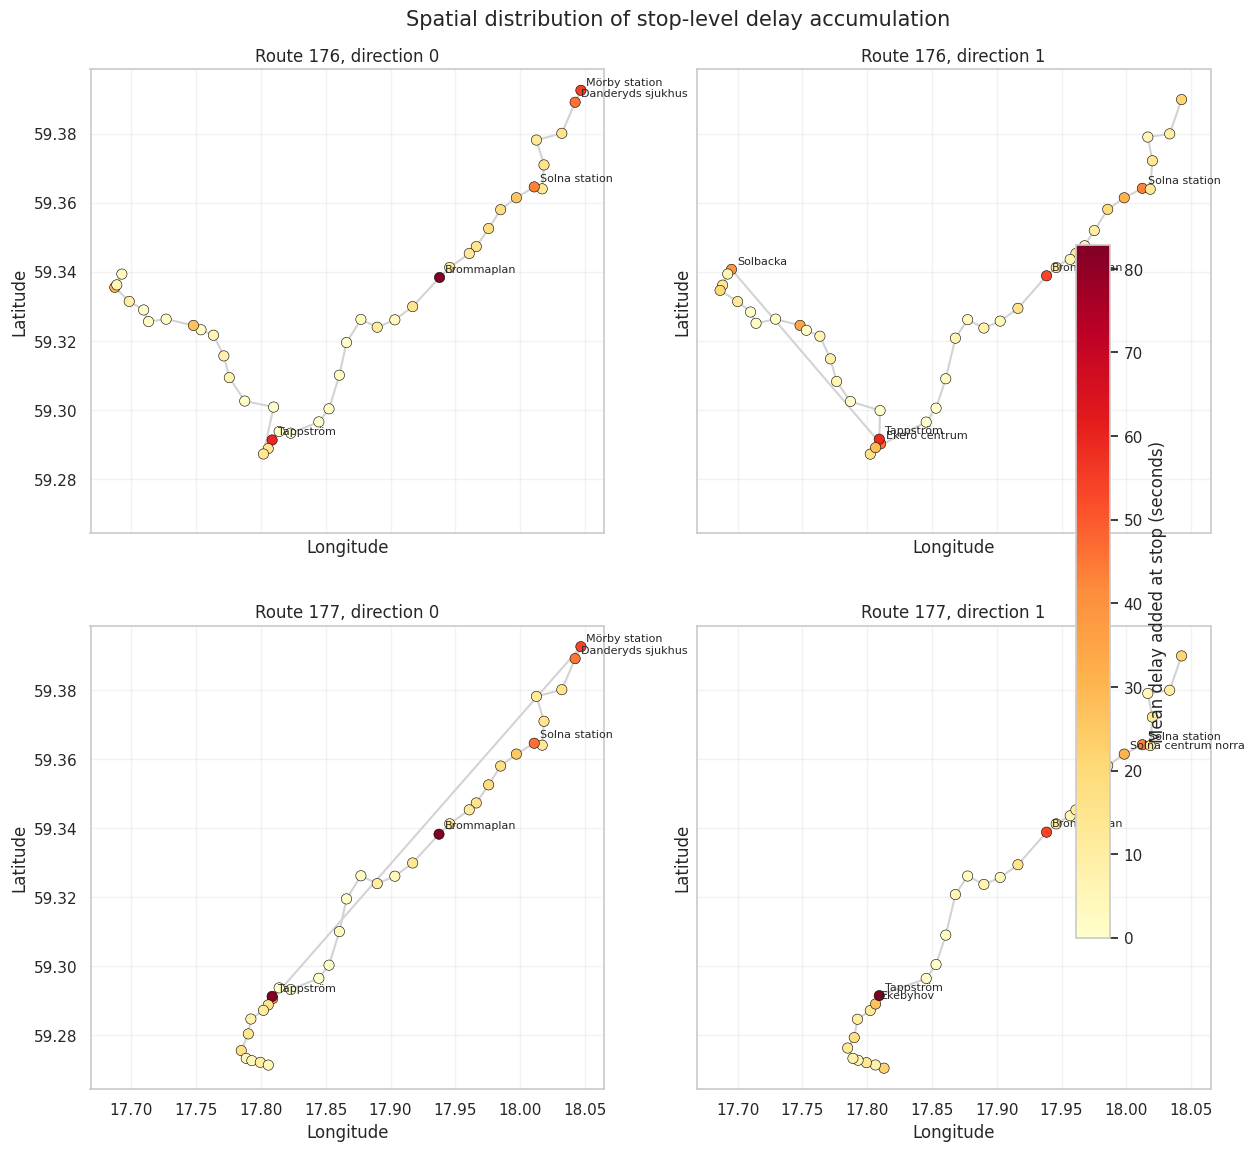

Figure saved to: /content/drive/MyDrive/AH2179_Final_Project_Bus_176_177/figures/figure_spatial_stop_delay_accumulation.png


In [21]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ---------------------------------------------------------
# Aggregate stop information for the spatial figure
# ---------------------------------------------------------

spatial_stop_summary = (
    model_data
    .dropna(
        subset=[
            "current_stop_name",
            "current_stop_lat",
            "current_stop_lon"
        ]
    )
    .groupby(
        [
            "LineNumber",
            "direction_id",
            "current_stop_name"
        ]
    )
    .agg(
        stop_lat=(
            "current_stop_lat",
            "median"
        ),
        stop_lon=(
            "current_stop_lon",
            "median"
        ),
        typical_sequence=(
            "stop_sequence",
            "median"
        ),
        observations=(
            "stop_delay_change_sec",
            "count"
        ),
        mean_delay_added_sec=(
            "stop_delay_change_sec",
            "mean"
        )
    )
    .reset_index()
)

# Use a common colour scale to make panels comparable
colour_min = 0
colour_max = spatial_stop_summary[
    "mean_delay_added_sec"
].quantile(0.98)

normalisation = Normalize(
    vmin=colour_min,
    vmax=colour_max
)

colour_map = plt.cm.YlOrRd

route_direction_pairs = [
    ("176", 0),
    ("176", 1),
    ("177", 0),
    ("177", 1)
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 12),
    sharex=True,
    sharey=True
)

for axis, (route, direction) in zip(
    axes.flat,
    route_direction_pairs
):

    panel_data = spatial_stop_summary[
        (spatial_stop_summary["LineNumber"] == route)
        & (
            spatial_stop_summary["direction_id"]
            == direction
        )
    ].sort_values("typical_sequence")

    # Light route alignment
    axis.plot(
        panel_data["stop_lon"],
        panel_data["stop_lat"],
        color="lightgray",
        linewidth=1.5,
        zorder=1
    )

    # Stops coloured by delay accumulation
    axis.scatter(
        panel_data["stop_lon"],
        panel_data["stop_lat"],
        c=panel_data["mean_delay_added_sec"],
        cmap=colour_map,
        norm=normalisation,
        s=55,
        edgecolor="black",
        linewidth=0.4,
        zorder=2
    )

    # Label the five strongest hotspots in each panel
    label_stops = (
        panel_data
        .nlargest(
            5,
            "mean_delay_added_sec"
        )
    )

    for _, stop in label_stops.iterrows():
        axis.annotate(
            stop["current_stop_name"],
            (
                stop["stop_lon"],
                stop["stop_lat"]
            ),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8
        )

    axis.set_title(
        f"Route {route}, direction {direction}"
    )
    axis.set_xlabel("Longitude")
    axis.set_ylabel("Latitude")
    axis.grid(alpha=0.25)

# Shared colour bar
colour_bar_object = ScalarMappable(
    norm=normalisation,
    cmap=colour_map
)

colour_bar_object.set_array([])

fig.colorbar(
    colour_bar_object,
    ax=axes.ravel().tolist(),
    label="Mean delay added at stop (seconds)",
    shrink=0.75
)

fig.suptitle(
    "Spatial distribution of stop-level delay accumulation",
    fontsize=15,
    y=0.98
)

plt.subplots_adjust(
    left=0.08,
    right=0.88,
    bottom=0.08,
    top=0.93,
    wspace=0.18,
    hspace=0.20
)

spatial_figure = (
    FIGURES_DIR /
    "figure_spatial_stop_delay_accumulation.png"
)

plt.savefig(
    spatial_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {spatial_figure}")

### Spatial interpretation

Delay accumulation is spatially concentrated at major interchange stops
rather than distributed uniformly along the routes. Tappström, Brommaplan,
Solna station and Danderyds sjukhus repeatedly appear as important hotspots
across routes and directions. The spatial results therefore support including
current-stop and next-stop identifiers as model features.

## 10. Feature engineering and chronological data split

The model predicts arrival delay at the next stop immediately after departure
from the current stop. Features therefore include information available at
that moment: current arrival and departure delay, dwell time, segment
distance, stop sequence, route, direction, stop identifiers and temporal
variables.

Cyclical transformations are used for hour, weekday and month because these
variables repeat over time. A chronological split is used instead of a random
split to avoid training the models on future observations. January–September
are used for training, October for validation and November–December for the
final test.

In [22]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Create modelling features
# ---------------------------------------------------------

ml_data = model_data.copy()

# Current operational conditions, expressed in practical units
ml_data["current_arrival_delay_min"] = (
    ml_data["observed_arrival_delay"] / 60
)

ml_data["current_departure_delay_min"] = (
    ml_data["observed_departure_delay"] / 60
)

ml_data["observed_dwell_min"] = (
    ml_data["observed_dwell_sec"] / 60
)

ml_data["excess_dwell_min"] = (
    ml_data["excess_dwell_sec"] / 60
)

ml_data["next_segment_distance_km"] = (
    ml_data["next_segment_distance_m"] / 1000
)

# Cyclical time variables
ml_data["hour_sin"] = np.sin(
    2 * np.pi * ml_data["scheduled_hour"] / 24
)

ml_data["hour_cos"] = np.cos(
    2 * np.pi * ml_data["scheduled_hour"] / 24
)

ml_data["weekday_sin"] = np.sin(
    2 * np.pi * ml_data["weekday"] / 7
)

ml_data["weekday_cos"] = np.cos(
    2 * np.pi * ml_data["weekday"] / 7
)

ml_data["month_sin"] = np.sin(
    2 * np.pi * ml_data["month"] / 12
)

ml_data["month_cos"] = np.cos(
    2 * np.pi * ml_data["month"] / 12
)

# Treat identifiers as categorical text
categorical_features = [
    "LineNumber",
    "direction_id",
    "current_stop_key",
    "next_stop_key"
]

for column in categorical_features:
    ml_data[column] = (
        ml_data[column]
        .astype("string")
    )

numeric_features = [
    "current_arrival_delay_min",
    "current_departure_delay_min",
    "observed_dwell_min",
    "excess_dwell_min",
    "next_segment_distance_km",
    "stop_sequence",
    "hour_sin",
    "hour_cos",
    "weekday_sin",
    "weekday_cos",
    "month_sin",
    "month_cos",
    "is_weekend"
]

target_column = "target_next_arrival_delay_min"

selected_columns = (
    ["date"]
    + categorical_features
    + numeric_features
    + [target_column]
)

ml_table = ml_data[selected_columns].copy()

# Replace infinite values and remove rows with missing model inputs
ml_table = ml_table.replace(
    [np.inf, -np.inf],
    np.nan
)

rows_before_feature_cleaning = len(ml_table)

ml_table = ml_table.dropna(
    subset=numeric_features + [target_column]
).reset_index(drop=True)

rows_removed_feature_cleaning = (
    rows_before_feature_cleaning
    - len(ml_table)
)

# ---------------------------------------------------------
# Chronological split
# ---------------------------------------------------------

train_data = ml_table[
    ml_table["date"] < "2024-10-01"
].copy()

validation_data = ml_table[
    (ml_table["date"] >= "2024-10-01")
    & (ml_table["date"] < "2024-11-01")
].copy()

test_data = ml_table[
    ml_table["date"] >= "2024-11-01"
].copy()

print("FEATURE-ENGINEERED DATASET")
print(f"Total observations: {len(ml_table):,}")
print(
    "Rows removed because of missing features:",
    f"{rows_removed_feature_cleaning:,}"
)

print("\nCHRONOLOGICAL SPLIT")
print(
    f"Training, Jan–Sep: {len(train_data):,} "
    f"({100 * len(train_data) / len(ml_table):.1f}%)"
)
print(
    f"Validation, Oct: {len(validation_data):,} "
    f"({100 * len(validation_data) / len(ml_table):.1f}%)"
)
print(
    f"Test, Nov–Dec: {len(test_data):,} "
    f"({100 * len(test_data) / len(ml_table):.1f}%)"
)

print("\nDATE RANGES")
print(
    "Training:",
    train_data["date"].min().date(),
    "to",
    train_data["date"].max().date()
)
print(
    "Validation:",
    validation_data["date"].min().date(),
    "to",
    validation_data["date"].max().date()
)
print(
    "Test:",
    test_data["date"].min().date(),
    "to",
    test_data["date"].max().date()
)

# Save the feature-engineered table
ml_table_file = (
    PROCESSED_DIR /
    "ml_table_176_177_2024.parquet"
)

ml_table.to_parquet(
    ml_table_file,
    index=False
)

print(f"\nSaved to: {ml_table_file}")

FEATURE-ENGINEERED DATASET
Total observations: 2,643,576
Rows removed because of missing features: 0

CHRONOLOGICAL SPLIT
Training, Jan–Sep: 1,966,871 (74.4%)
Validation, Oct: 228,139 (8.6%)
Test, Nov–Dec: 448,566 (17.0%)

DATE RANGES
Training: 2024-01-01 to 2024-09-30
Validation: 2024-10-01 to 2024-10-31
Test: 2024-11-01 to 2024-12-31

Saved to: /content/drive/MyDrive/AH2179_Final_Project_Bus_176_177/data/processed/ml_table_176_177_2024.parquet


## 11. Baseline models

Two operational baselines are evaluated before developing machine-learning
models. The schedule baseline predicts zero delay, while the persistence
baseline assumes that the current departure delay continues unchanged to the
next stop.

MAE and RMSE are used as the main evaluation metrics. MAPE is not suitable
because delay values can be zero or negative.

In [23]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def regression_metrics(y_true, y_pred):
    """Calculate regression evaluation metrics."""

    return {
        "MAE_min": mean_absolute_error(
            y_true,
            y_pred
        ),
        "RMSE_min": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        ),
        "R2": r2_score(
            y_true,
            y_pred
        )
    }


baseline_results = []

for split_name, split_data in [
    ("Validation", validation_data),
    ("Test", test_data)
]:
    y_true = split_data[target_column]

    # Baseline 1: no delay
    schedule_prediction = np.zeros(
        len(split_data)
    )

    schedule_metrics = regression_metrics(
        y_true,
        schedule_prediction
    )

    baseline_results.append({
        "split": split_name,
        "model": "Schedule baseline",
        **schedule_metrics
    })

    # Baseline 2: current delay continues to next stop
    persistence_prediction = split_data[
        "current_departure_delay_min"
    ].to_numpy()

    persistence_metrics = regression_metrics(
        y_true,
        persistence_prediction
    )

    baseline_results.append({
        "split": split_name,
        "model": "Persistence baseline",
        **persistence_metrics
    })

baseline_results = pd.DataFrame(
    baseline_results
)

print("BASELINE RESULTS")
display(
    baseline_results.round(3)
)

BASELINE RESULTS


,split,model,MAE_min,RMSE_min,R2
0,Validation,Schedule baseline,4.629,9.039,-0.253
1,Validation,Persistence baseline,0.666,1.787,0.951
2,Test,Schedule baseline,3.974,8.416,-0.181
3,Test,Persistence baseline,0.630,1.771,0.948


### Baseline interpretation

The persistence baseline substantially outperforms the schedule baseline.
On the final test period, persistence achieves an MAE of 0.630 minutes,
approximately 38 seconds, and an R² of 0.948. This confirms strong short-term
delay propagation between consecutive stops.

The result also establishes a demanding benchmark. A complex model should
only be recommended if it provides a meaningful improvement over persistence,
which is simple, transparent and inexpensive to deploy.

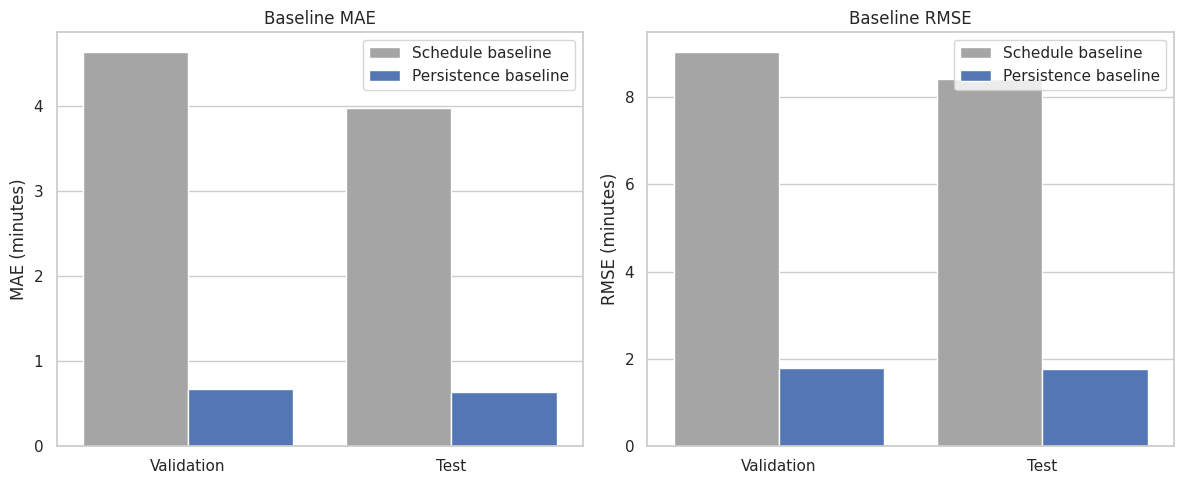

Figure saved to: /content/drive/MyDrive/AH2179_Final_Project_Bus_176_177/figures/figure_baseline_model_comparison.png


In [24]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

sns.barplot(
    data=baseline_results,
    x="split",
    y="MAE_min",
    hue="model",
    ax=axes[0],
    palette=["#A5A5A5", "#4472C4"]
)

axes[0].set_title("Baseline MAE")
axes[0].set_xlabel("")
axes[0].set_ylabel("MAE (minutes)")
axes[0].legend(title="")

sns.barplot(
    data=baseline_results,
    x="split",
    y="RMSE_min",
    hue="model",
    ax=axes[1],
    palette=["#A5A5A5", "#4472C4"]
)

axes[1].set_title("Baseline RMSE")
axes[1].set_xlabel("")
axes[1].set_ylabel("RMSE (minutes)")
axes[1].legend(title="")

plt.tight_layout()

baseline_figure = (
    FIGURES_DIR /
    "figure_baseline_model_comparison.png"
)

plt.savefig(
    baseline_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {baseline_figure}")

## 12. Model 1 – Regularised linear regression

Ridge regression is used as the first machine-learning model. Numerical
features are standardised and categorical variables are one-hot encoded.
Regularisation reduces instability caused by correlated delay and dwell-time
features.

Three regularisation strengths are compared using the October validation
period. The final November–December test set is evaluated only after the
hyperparameter has been selected.

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
import joblib
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Prepare model inputs
# ---------------------------------------------------------

feature_columns = (
    numeric_features
    + categorical_features
)

X_train = train_data[feature_columns]
y_train = train_data[target_column].astype("float32")

X_validation = validation_data[feature_columns]
y_validation = validation_data[target_column].astype(
    "float32"
)

X_test = test_data[feature_columns]
y_test = test_data[target_column].astype("float32")

# Numerical variables are scaled.
# Categorical variables are converted to sparse dummy variables.
linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(with_mean=False),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                dtype=np.float32
            ),
            categorical_features
        )
    ],
    sparse_threshold=1.0
)

print("Transforming training data...")

X_train_transformed = (
    linear_preprocessor.fit_transform(X_train)
)

print("Transforming validation data...")

X_validation_transformed = (
    linear_preprocessor.transform(X_validation)
)

print("Transformed training shape:")
print(X_train_transformed.shape)

Transforming training data...
Transforming validation data...
Transformed training shape:
(1966871, 217)


In [26]:
# ---------------------------------------------------------
# Tune Ridge regularisation using validation data
# ---------------------------------------------------------

ridge_candidates = {}
ridge_validation_results = []

for alpha in [0.1, 1.0, 10.0]:

    print(f"Training Ridge with alpha={alpha}...")

    ridge_model = Ridge(
        alpha=alpha,
        solver="lsqr",
        max_iter=1000,
        tol=1e-4
    )

    ridge_model.fit(
        X_train_transformed,
        y_train
    )

    validation_prediction = ridge_model.predict(
        X_validation_transformed
    )

    metrics = regression_metrics(
        y_validation,
        validation_prediction
    )

    ridge_candidates[alpha] = ridge_model

    ridge_validation_results.append({
        "alpha": alpha,
        "split": "Validation",
        **metrics
    })

ridge_validation_results = pd.DataFrame(
    ridge_validation_results
)

print("RIDGE VALIDATION RESULTS")
display(
    ridge_validation_results.round(4)
)

# Select alpha using validation MAE only
best_alpha = (
    ridge_validation_results
    .sort_values("MAE_min")
    .iloc[0]["alpha"]
)

best_ridge = ridge_candidates[best_alpha]

print(f"Selected alpha: {best_alpha}")

Training Ridge with alpha=0.1...
Training Ridge with alpha=1.0...
Training Ridge with alpha=10.0...
RIDGE VALIDATION RESULTS


,alpha,split,MAE_min,RMSE_min,R2
0,0.1,Validation,0.3785,1.6059,0.9605
1,1.0,Validation,0.3785,1.6059,0.9605
2,10.0,Validation,0.3785,1.6059,0.9604


Selected alpha: 10.0


In [27]:
# ---------------------------------------------------------
# Evaluate the selected Ridge model on the final test set
# ---------------------------------------------------------

print("Transforming test data...")

X_test_transformed = (
    linear_preprocessor.transform(X_test)
)

ridge_validation_prediction = (
    best_ridge.predict(
        X_validation_transformed
    )
)

ridge_test_prediction = (
    best_ridge.predict(
        X_test_transformed
    )
)

ridge_final_results = pd.DataFrame([
    {
        "split": "Validation",
        "model": f"Ridge (alpha={best_alpha:g})",
        **regression_metrics(
            y_validation,
            ridge_validation_prediction
        )
    },
    {
        "split": "Test",
        "model": f"Ridge (alpha={best_alpha:g})",
        **regression_metrics(
            y_test,
            ridge_test_prediction
        )
    }
])

print("SELECTED RIDGE RESULTS")
display(
    ridge_final_results.round(4)
)

# Save the complete preprocessing and model pipeline
ridge_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            linear_preprocessor
        ),
        (
            "model",
            best_ridge
        )
    ]
)

ridge_model_file = (
    MODELS_DIR /
    "ridge_next_stop_delay.joblib"
)

joblib.dump(
    ridge_pipeline,
    ridge_model_file
)

print(f"Ridge model saved to: {ridge_model_file}")

Transforming test data...
SELECTED RIDGE RESULTS


,split,model,MAE_min,RMSE_min,R2
0,Validation,Ridge (alpha=10),0.3785,1.6059,0.9604
1,Test,Ridge (alpha=10),0.3844,1.6116,0.9567


Ridge model saved to: /content/drive/MyDrive/AH2179_Final_Project_Bus_176_177/models/ridge_next_stop_delay.joblib


## 8.2 Non-linear tree model: XGBoost

Ridge regression assumes that the relationship between the explanatory
variables and the next-stop delay is approximately linear. However, delay
propagation may depend on non-linear interactions between the current delay,
dwell time, stop location, time of day, route and direction.

An XGBoost regression model is therefore developed as the second machine
learning model. A subset of the training period is used for efficient
hyperparameter comparison, while the complete October validation set is kept
for model selection. The selected configuration is subsequently trained on
the complete January–September training data and evaluated on the untouched
November–December test set.

In [28]:
# ============================================================
# VARIABLE ALIASES FOR XGBOOST
# ============================================================
# The Ridge section used slightly different variable names.
# These aliases allow the XGBoost code to reuse the already
# transformed matrices without repeating preprocessing.

X_train_encoded = X_train_transformed
X_val_encoded = X_validation_transformed
X_test_encoded = X_test_transformed

y_val = y_validation

print("Variables prepared for XGBoost:")
print("Training:", X_train_encoded.shape, y_train.shape)
print("Validation:", X_val_encoded.shape, y_val.shape)
print("Test:", X_test_encoded.shape, y_test.shape)

Variables prepared for XGBoost:
Training: (1966871, 217) (1966871,)
Validation: (228139, 217) (228139,)
Test: (448566, 217) (448566,)


In [29]:
# ============================================================
# MODEL 2: XGBOOST REGRESSION
# ============================================================

import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ------------------------------------------------------------
# 1. Evaluation function
# ------------------------------------------------------------

def regression_metrics(y_true, y_pred, split, model_name):
    """Return the main regression metrics used in the project."""

    return {
        "split": split,
        "model": model_name,
        "MAE_min": mean_absolute_error(y_true, y_pred),
        "RMSE_min": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }


# ------------------------------------------------------------
# 2. Create a reproducible tuning sample
# ------------------------------------------------------------
# Hyperparameter comparison is performed on a training subset to
# reduce computation time. All sampled observations still come from
# the January–September training period.

rng = np.random.default_rng(42)

tuning_sample_size = min(600_000, X_train_encoded.shape[0])

tuning_indices = np.sort(
    rng.choice(
        X_train_encoded.shape[0],
        size=tuning_sample_size,
        replace=False
    )
)

X_train_tune = X_train_encoded[tuning_indices]
y_train_tune = np.asarray(y_train)[tuning_indices]

print("XGBoost tuning sample:", X_train_tune.shape)
print("Complete validation set:", X_val_encoded.shape)


# ------------------------------------------------------------
# 3. Candidate configurations
# ------------------------------------------------------------
# The configurations vary model depth and learning rate.
# Early stopping determines the useful number of boosting trees.

xgb_configurations = [
    {
        "name": "Shallow",
        "max_depth": 4,
        "learning_rate": 0.08,
        "min_child_weight": 10
    },
    {
        "name": "Medium",
        "max_depth": 6,
        "learning_rate": 0.05,
        "min_child_weight": 10
    },
    {
        "name": "Deep",
        "max_depth": 8,
        "learning_rate": 0.04,
        "min_child_weight": 15
    }
]


tuning_results = []
candidate_models = {}

for config in xgb_configurations:

    print(f"\nTraining XGBoost configuration: {config['name']}")
    start_time = time.time()

    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=1200,
        max_depth=config["max_depth"],
        learning_rate=config["learning_rate"],
        min_child_weight=config["min_child_weight"],
        subsample=0.80,
        colsample_bytree=0.80,
        reg_alpha=0.05,
        reg_lambda=1.0,
        tree_method="hist",
        early_stopping_rounds=40,
        random_state=42,
        n_jobs=-1,
        eval_metric="mae"
    )

    model.fit(
        X_train_tune,
        y_train_tune,
        eval_set=[(X_val_encoded, y_val)],
        verbose=False
    )

    val_prediction = model.predict(X_val_encoded)

    result = regression_metrics(
        y_val,
        val_prediction,
        split="Validation",
        model_name=f"XGBoost {config['name']}"
    )

    result["configuration"] = config["name"]
    result["best_iteration"] = model.best_iteration
    result["training_minutes"] = (time.time() - start_time) / 60

    tuning_results.append(result)
    candidate_models[config["name"]] = model


xgb_tuning_results = pd.DataFrame(tuning_results).sort_values("MAE_min")

print("\nXGBOOST VALIDATION RESULTS")
display(
    xgb_tuning_results[
        [
            "configuration",
            "MAE_min",
            "RMSE_min",
            "R2",
            "best_iteration",
            "training_minutes"
        ]
    ].round(4)
)


# ------------------------------------------------------------
# 4. Select the best configuration
# ------------------------------------------------------------

best_configuration_name = xgb_tuning_results.iloc[0]["configuration"]

best_configuration = next(
    config for config in xgb_configurations
    if config["name"] == best_configuration_name
)

best_candidate = candidate_models[best_configuration_name]

# best_iteration is zero-indexed, therefore add one
selected_number_of_trees = int(best_candidate.best_iteration) + 1

print("\nSelected configuration:", best_configuration_name)
print("Selected number of trees:", selected_number_of_trees)


# ------------------------------------------------------------
# 5. Train the selected configuration on all training observations
# ------------------------------------------------------------

print("\nTraining selected XGBoost model on the complete training set...")
start_time = time.time()

xgb_final = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=selected_number_of_trees,
    max_depth=best_configuration["max_depth"],
    learning_rate=best_configuration["learning_rate"],
    min_child_weight=best_configuration["min_child_weight"],
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.05,
    reg_lambda=1.0,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    eval_metric="mae"
)

xgb_final.fit(
    X_train_encoded,
    y_train,
    verbose=False
)

print(
    "Complete training time:",
    round((time.time() - start_time) / 60, 2),
    "minutes"
)


# ------------------------------------------------------------
# 6. Evaluate on validation and untouched test data
# ------------------------------------------------------------

xgb_val_prediction = xgb_final.predict(X_val_encoded)
xgb_test_prediction = xgb_final.predict(X_test_encoded)

xgb_results = pd.DataFrame([
    regression_metrics(
        y_val,
        xgb_val_prediction,
        "Validation",
        f"XGBoost {best_configuration_name}"
    ),
    regression_metrics(
        y_test,
        xgb_test_prediction,
        "Test",
        f"XGBoost {best_configuration_name}"
    )
])

print("\nSELECTED XGBOOST RESULTS")
display(xgb_results.round(4))


# ------------------------------------------------------------
# 7. Save the trained model and preprocessing information
# ------------------------------------------------------------
# The preprocessing object is included because XGBoost expects the
# same 217 encoded features when applied to new observations.

xgb_model_path = MODELS_DIR / "xgboost_next_stop_delay.joblib"

joblib.dump(
    {
        "preprocessor": preprocessor,
        "model": xgb_final,
        "numerical_features": numerical_features,
        "categorical_features": categorical_features,
        "selected_configuration": best_configuration,
        "number_of_trees": selected_number_of_trees
    },
    xgb_model_path
)

print("XGBoost model saved to:", xgb_model_path)


# ------------------------------------------------------------
# 8. Compare XGBoost with Ridge and the persistence baseline
# ------------------------------------------------------------

comparison_results = pd.DataFrame([
    {
        "model": "Persistence baseline",
        "MAE_min": mean_absolute_error(y_test, persistence_test_pred),
        "RMSE_min": np.sqrt(
            mean_squared_error(y_test, persistence_test_pred)
        )
    },
    {
        "model": "Ridge regression",
        "MAE_min": mean_absolute_error(y_test, ridge_test_prediction),
        "RMSE_min": np.sqrt(
            mean_squared_error(y_test, ridge_test_prediction)
        )
    },
    {
        "model": "XGBoost",
        "MAE_min": mean_absolute_error(y_test, xgb_test_prediction),
        "RMSE_min": np.sqrt(
            mean_squared_error(y_test, xgb_test_prediction)
        )
    }
])


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(
    comparison_results["model"],
    comparison_results["MAE_min"],
    color=["#9e9e9e", "#4472c4", "#70ad47"]
)
axes[0].set_title("Test MAE by model")
axes[0].set_ylabel("MAE (minutes)")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(
    comparison_results["model"],
    comparison_results["RMSE_min"],
    color=["#9e9e9e", "#4472c4", "#70ad47"]
)
axes[1].set_title("Test RMSE by model")
axes[1].set_ylabel("RMSE (minutes)")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", alpha=0.25)

plt.suptitle(
    "Next-stop delay prediction: baseline and machine-learning models",
    fontsize=13
)
plt.tight_layout()

comparison_figure_path = (
    FIGURES_DIR / "figure_xgboost_model_comparison.png"
)

plt.savefig(
    comparison_figure_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("\nTEST MODEL COMPARISON")
display(comparison_results.round(4))

print("Figure saved to:", comparison_figure_path)

XGBoost tuning sample: (600000, 217)
Complete validation set: (228139, 217)

Training XGBoost configuration: Shallow

Training XGBoost configuration: Medium

Training XGBoost configuration: Deep

XGBOOST VALIDATION RESULTS


,configuration,MAE_min,RMSE_min,R2,best_iteration,training_minutes
1,Medium,0.5377,2.0975,0.9325,619,15.3521
2,Deep,0.5383,2.1413,0.9297,785,19.4300
0,Shallow,0.5624,2.1855,0.9268,629,15.4677



Selected configuration: Medium
Selected number of trees: 620

Training selected XGBoost model on the complete training set...
Complete training time: 2.27 minutes

SELECTED XGBOOST RESULTS


,split,model,MAE_min,RMSE_min,R2
0,Validation,XGBoost Medium,0.5770,2.3844,0.9128
1,Test,XGBoost Medium,0.5707,2.5597,0.8907


NameError: name 'preprocessor' is not defined

### Final XGBoost training with early stopping

The number of boosting iterations selected from the smaller tuning sample may
not be optimal when the complete training dataset is used. The selected
medium-depth configuration is therefore retrained on all January–September
observations with early stopping against the October validation period.

This allows the final number of trees to adapt to the complete training
dataset while the November–December test period remains untouched.

Retraining XGBoost Medium on the complete training dataset...
Best iteration: 829
Training time: 22.6 minutes

FINAL XGBOOST RESULTS


,split,model,MAE_min,RMSE_min,R2
0,Validation,XGBoost Medium,0.5715,2.3781,0.9133
1,Test,XGBoost Medium,0.5726,2.6079,0.8866



Preprocessor candidates found:
- linear_preprocessor
- ridge_pipeline.preprocessor

XGBoost model and preprocessor saved to:
/content/drive/MyDrive/AH2179_Final_Project_Bus_176_177/models/xgboost_next_stop_delay.joblib


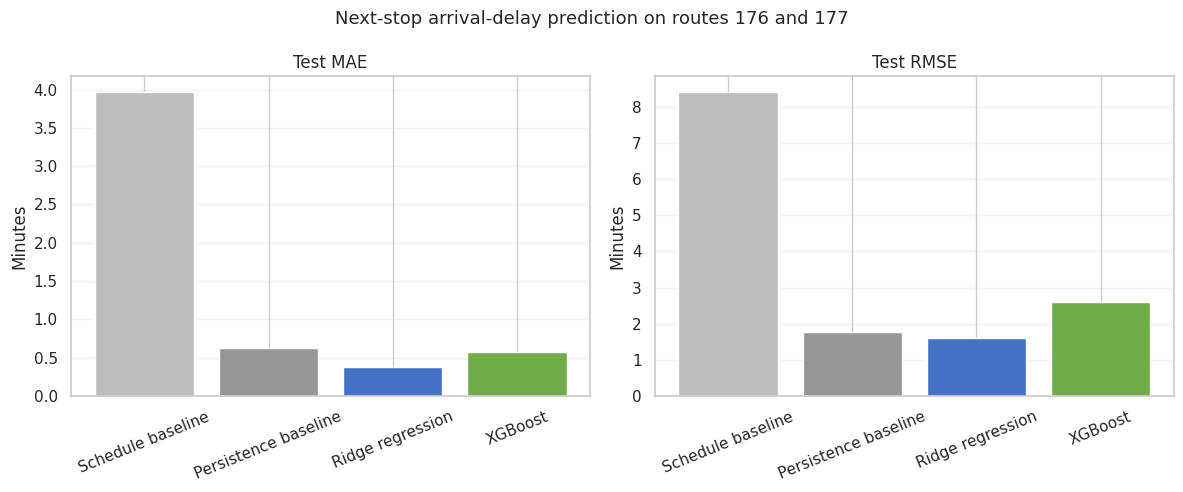


TEST MODEL COMPARISON


,model,MAE_min,RMSE_min
0,Schedule baseline,3.9740,8.4160
1,Persistence baseline,0.6300,1.7710
2,Ridge regression,0.3844,1.6116
3,XGBoost,0.5726,2.6079


Figure saved to: /content/drive/MyDrive/AH2179_Final_Project_Bus_176_177/figures/figure_xgboost_model_comparison.png


In [30]:
# ============================================================
# FINAL XGBOOST TRAINING WITH EARLY STOPPING
# ============================================================

import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ------------------------------------------------------------
# 1. Retrain the selected Medium configuration
# ------------------------------------------------------------

print("Retraining XGBoost Medium on the complete training dataset...")
start_time = time.time()

xgb_final = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1600,
    max_depth=6,
    learning_rate=0.05,
    min_child_weight=10,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.05,
    reg_lambda=1.0,
    tree_method="hist",
    early_stopping_rounds=40,
    random_state=42,
    n_jobs=-1,
    eval_metric="mae"
)

xgb_final.fit(
    X_train_encoded,
    y_train,
    eval_set=[(X_val_encoded, y_val)],
    verbose=False
)

training_minutes = (time.time() - start_time) / 60

print("Best iteration:", xgb_final.best_iteration)
print("Training time:", round(training_minutes, 2), "minutes")


# ------------------------------------------------------------
# 2. Predictions and evaluation
# ------------------------------------------------------------

xgb_val_prediction = xgb_final.predict(X_val_encoded)
xgb_test_prediction = xgb_final.predict(X_test_encoded)


def calculate_metrics(y_true, y_pred, split):
    return {
        "split": split,
        "model": "XGBoost Medium",
        "MAE_min": mean_absolute_error(y_true, y_pred),
        "RMSE_min": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }


xgb_final_results = pd.DataFrame([
    calculate_metrics(y_val, xgb_val_prediction, "Validation"),
    calculate_metrics(y_test, xgb_test_prediction, "Test")
])

print("\nFINAL XGBOOST RESULTS")
display(xgb_final_results.round(4))


# ------------------------------------------------------------
# 3. Locate the fitted ColumnTransformer from the Ridge section
# ------------------------------------------------------------

preprocessor_candidates = []

for variable_name, variable_value in globals().copy().items():

    if isinstance(variable_value, ColumnTransformer):
        preprocessor_candidates.append(
            (variable_name, variable_value)
        )

    elif isinstance(variable_value, Pipeline):
        for step_name, step_object in variable_value.named_steps.items():
            if isinstance(step_object, ColumnTransformer):
                preprocessor_candidates.append(
                    (
                        f"{variable_name}.{step_name}",
                        step_object
                    )
                )

print("\nPreprocessor candidates found:")
for candidate_name, _ in preprocessor_candidates:
    print("-", candidate_name)


# ------------------------------------------------------------
# 4. Save model
# ------------------------------------------------------------

xgb_model_path = MODELS_DIR / "xgboost_next_stop_delay.joblib"

if len(preprocessor_candidates) >= 1:

    fitted_preprocessor = preprocessor_candidates[0][1]

    joblib.dump(
        {
            "preprocessor": fitted_preprocessor,
            "model": xgb_final,
            "input_columns": list(X_train.columns),
            "encoded_feature_count": X_train_encoded.shape[1],
            "configuration": {
                "max_depth": 6,
                "learning_rate": 0.05,
                "min_child_weight": 10,
                "subsample": 0.80,
                "colsample_bytree": 0.80,
                "reg_alpha": 0.05,
                "reg_lambda": 1.0,
                "best_iteration": int(xgb_final.best_iteration)
            }
        },
        xgb_model_path
    )

    print("\nXGBoost model and preprocessor saved to:")
    print(xgb_model_path)

else:
    # Save the trained model even if the preprocessing object cannot
    # automatically be located.
    joblib.dump(
        {
            "model": xgb_final,
            "input_columns": list(X_train.columns),
            "encoded_feature_count": X_train_encoded.shape[1]
        },
        xgb_model_path
    )

    print("\nNo ColumnTransformer was found automatically.")
    print("The trained XGBoost model was saved without preprocessing:")
    print(xgb_model_path)


# ------------------------------------------------------------
# 5. Test-set comparison figure
# ------------------------------------------------------------

xgb_test_mae = mean_absolute_error(y_test, xgb_test_prediction)
xgb_test_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_test_prediction)
)

# Previously obtained test results
model_comparison = pd.DataFrame({
    "model": [
        "Schedule baseline",
        "Persistence baseline",
        "Ridge regression",
        "XGBoost"
    ],
    "MAE_min": [
        3.9740,
        0.6300,
        0.3844,
        xgb_test_mae
    ],
    "RMSE_min": [
        8.4160,
        1.7710,
        1.6116,
        xgb_test_rmse
    ]
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ["#bdbdbd", "#969696", "#4472c4", "#70ad47"]

axes[0].bar(
    model_comparison["model"],
    model_comparison["MAE_min"],
    color=colors
)
axes[0].set_title("Test MAE")
axes[0].set_ylabel("Minutes")
axes[0].tick_params(axis="x", rotation=22)
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(
    model_comparison["model"],
    model_comparison["RMSE_min"],
    color=colors
)
axes[1].set_title("Test RMSE")
axes[1].set_ylabel("Minutes")
axes[1].tick_params(axis="x", rotation=22)
axes[1].grid(axis="y", alpha=0.25)

plt.suptitle(
    "Next-stop arrival-delay prediction on routes 176 and 177",
    fontsize=13
)
plt.tight_layout()

figure_path = (
    FIGURES_DIR / "figure_xgboost_model_comparison.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("\nTEST MODEL COMPARISON")
display(model_comparison.round(4))

print("Figure saved to:", figure_path)

In [33]:
X_train_encoded = X_train_transformed
X_validation_encoded = X_validation_transformed
X_test_encoded = X_test_transformed

print("Training:", X_train_encoded.shape)
print("Validation:", X_validation_encoded.shape)
print("Test:", X_test_encoded.shape)

Training: (1966871, 217)
Validation: (228139, 217)
Test: (448566, 217)


In [34]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

np.random.seed(42)
tf.random.set_seed(42)

nn_model = keras.Sequential([
    keras.layers.Input(
        shape=(X_train_encoded.shape[1],),
        sparse=True
    ),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1)
])

nn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.Huber(),
    metrics=[keras.metrics.MeanAbsoluteError(name="mae")]
)

keras_path = MODELS_DIR / "best_next_stop_delay_model.keras"

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_mae",
        patience=3,
        mode="min",
        restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        str(keras_path),
        monitor="val_mae",
        mode="min",
        save_best_only=True
    )
]

history = nn_model.fit(
    X_train_encoded,
    y_train,
    validation_data=(
        X_validation_encoded,
        y_validation
    ),
    epochs=15,
    batch_size=4096,
    callbacks=callbacks,
    verbose=1
)

nn_model = keras.models.load_model(str(keras_path))

nn_validation_prediction = nn_model.predict(
    X_validation_encoded,
    batch_size=4096
).ravel()

nn_test_prediction = nn_model.predict(
    X_test_encoded,
    batch_size=4096
).ravel()

nn_results = pd.DataFrame([
    {
        "split": "Validation",
        "model": "Keras neural network",
        **regression_metrics(
            y_validation,
            nn_validation_prediction
        )
    },
    {
        "split": "Test",
        "model": "Keras neural network",
        **regression_metrics(
            y_test,
            nn_test_prediction
        )
    }
])

display(nn_results.round(4))
print("Model saved to:", keras_path)

Epoch 1/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 26s 49ms/step - loss: 0.3658 - mae: 0.5977 - val_loss: 0.1640 - val_mae: 0.3618
Epoch 2/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step - loss: 0.0900 - mae: 0.2669 - val_loss: 0.1557 - val_mae: 0.3465
Epoch 3/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 26s 53ms/step - loss: 0.0868 - mae: 0.2596 - val_loss: 0.1520 - val_mae: 0.3382
Epoch 4/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 24s 50ms/step - loss: 0.0852 - mae: 0.2562 - val_loss: 0.1499 - val_mae: 0.3334
Epoch 5/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - loss: 0.0843 - mae: 0.2543 - val_loss: 0.1486 - val_mae: 0.3307
Epoch 6/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - loss: 0.0836 - mae: 0.2528 - val_loss: 0.1474 - val_mae: 0.3286
Epoch 7/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - loss: 0.0828 - mae: 0.2511 - val_loss: 0.1456 - val_mae: 0.3245
Epoch 8/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - loss: 0.0820 - mae: 0.2495 - val_loss: 0.1445 - val_mae: 0.3224
Epoch 9/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 

TypeError: regression_metrics() missing 2 required positional arguments: 'split' and 'model_name'

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

nn_results = pd.DataFrame([
    {
        "split": "Validation",
        "model": "Keras neural network",
        "MAE_min": mean_absolute_error(
            y_validation,
            nn_validation_prediction
        ),
        "RMSE_min": np.sqrt(mean_squared_error(
            y_validation,
            nn_validation_prediction
        )),
        "R2": r2_score(
            y_validation,
            nn_validation_prediction
        )
    },
    {
        "split": "Test",
        "model": "Keras neural network",
        "MAE_min": mean_absolute_error(
            y_test,
            nn_test_prediction
        ),
        "RMSE_min": np.sqrt(mean_squared_error(
            y_test,
            nn_test_prediction
        )),
        "R2": r2_score(
            y_test,
            nn_test_prediction
        )
    }
])

display(nn_results.round(4))

,split,model,MAE_min,RMSE_min,R2
0,Validation,Keras neural network,0.3185,1.5738,0.9620
1,Test,Keras neural network,0.3477,1.5987,0.9574


### Neural network interpretation

The neural network achieved the best overall performance, with a test MAE of
0.348 minutes, equivalent to approximately 21 seconds. Its test RMSE was 1.599
minutes and its R² was 0.957. The small difference between validation and test
performance indicates good temporal generalisation. However, the higher RMSE
shows that unusually large delays remain more difficult to predict.

In [36]:
final_results = pd.DataFrame([
    {
        "Model": "Schedule baseline",
        "Test_MAE_min": 3.9740,
        "Test_RMSE_min": 8.4160
    },
    {
        "Model": "Persistence baseline",
        "Test_MAE_min": 0.6300,
        "Test_RMSE_min": 1.7710
    },
    {
        "Model": "Ridge regression",
        "Test_MAE_min": 0.3844,
        "Test_RMSE_min": 1.6116
    },
    {
        "Model": "XGBoost",
        "Test_MAE_min": 0.5726,
        "Test_RMSE_min": 2.6079
    },
    {
        "Model": "Keras neural network",
        "Test_MAE_min": 0.3477,
        "Test_RMSE_min": 1.5987
    }
]).sort_values("Test_MAE_min").reset_index(drop=True)

display(final_results)

final_results.to_csv(
    MODELS_DIR / "final_model_comparison.csv",
    index=False
)

joblib.dump(
    linear_preprocessor,
    MODELS_DIR / "next_stop_preprocessor.joblib"
)

print("Selected final model: Keras neural network")
print("Model and preprocessing files saved.")

,Model,Test_MAE_min,Test_RMSE_min
0,Keras neural network,0.3477,1.5987
1,Ridge regression,0.3844,1.6116
2,XGBoost,0.5726,2.6079
3,Persistence baseline,0.6300,1.7710
4,Schedule baseline,3.9740,8.4160


Selected final model: Keras neural network
Model and preprocessing files saved.


In [38]:
diagnostics = test_data[
    ["LineNumber", "direction_id"]
].copy()

diagnostics["actual"] = y_test.to_numpy()
diagnostics["prediction"] = nn_test_prediction

# Reconstruct time variables from cyclical features
diagnostics["scheduled_hour"] = (
    np.rint(
        (
            np.arctan2(
                test_data["hour_sin"],
                test_data["hour_cos"]
            ) % (2 * np.pi)
        ) * 24 / (2 * np.pi)
    ).astype(int) % 24
)

diagnostics["weekday"] = (
    np.rint(
        (
            np.arctan2(
                test_data["weekday_sin"],
                test_data["weekday_cos"]
            ) % (2 * np.pi)
        ) * 7 / (2 * np.pi)
    ).astype(int) % 7
)

reconstructed_month = (
    np.rint(
        (
            np.arctan2(
                test_data["month_sin"],
                test_data["month_cos"]
            ) % (2 * np.pi)
        ) * 12 / (2 * np.pi)
    ).astype(int) % 12
)

diagnostics["month"] = np.where(
    reconstructed_month == 0,
    12,
    reconstructed_month
)

diagnostics["error"] = (
    diagnostics["prediction"]
    - diagnostics["actual"]
)

diagnostics["absolute_error"] = diagnostics["error"].abs()
diagnostics["squared_error"] = diagnostics["error"] ** 2

diagnostics["delay_level"] = pd.cut(
    diagnostics["actual"],
    bins=[-np.inf, 0, 5, 15, 30, np.inf],
    labels=[
        "Early or on time",
        "0–5 min",
        "5–15 min",
        "15–30 min",
        "Above 30 min"
    ]
)

def diagnostic_summary(group_column):
    return (
        diagnostics
        .groupby(group_column, observed=True)
        .agg(
            observations=("absolute_error", "size"),
            MAE_min=("absolute_error", "mean"),
            RMSE_min=(
                "squared_error",
                lambda values: np.sqrt(values.mean())
            ),
            bias_min=("error", "mean")
        )
        .reset_index()
    )

diagnostic_tables = {}

for column in [
    "LineNumber",
    "direction_id",
    "scheduled_hour",
    "weekday",
    "month",
    "delay_level"
]:
    table = diagnostic_summary(column)
    diagnostic_tables[column] = table

    print(f"\nDiagnostics by {column}")
    display(table.round(3))

diagnostics.to_parquet(
    MODELS_DIR / "keras_test_diagnostics.parquet",
    index=False
)

print("Diagnostics saved.")


Diagnostics by LineNumber


,LineNumber,observations,MAE_min,RMSE_min,bias_min
0,176,246331,0.324,1.556,-0.048
1,177,202235,0.377,1.650,-0.042



Diagnostics by direction_id


,direction_id,observations,MAE_min,RMSE_min,bias_min
0,0,230726,0.322,1.034,-0.042
1,1,217840,0.375,2.032,-0.049



Diagnostics by scheduled_hour


...


Diagnostics by month


,month,observations,MAE_min,RMSE_min,bias_min
0,11,216105,0.331,1.926,-0.077
1,12,232461,0.363,1.218,-0.017



Diagnostics by delay_level


,delay_level,observations,MAE_min,RMSE_min,bias_min
0,Early or on time,99193,0.366,0.817,0.101
1,0–5 min,265627,0.260,0.436,-0.010
2,5–15 min,65778,0.358,0.810,-0.108
3,15–30 min,11319,0.761,2.678,-0.420
4,Above 30 min,6649,2.772,11.670,-2.411


Diagnostics saved.


In [3]:

from google.colab import drive
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
from tensorflow import keras

drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/AH2179_Final_Project_Bus_176_177"
)

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
RAW_DIR = PROJECT_DIR / "data" / "raw"
MODELS_DIR = PROJECT_DIR / "models"

# Load only November–December
ml_table_file = (
    PROCESSED_DIR / "ml_table_176_177_2024.parquet"
)

test_data = pd.read_parquet(
    ml_table_file,
    filters=[
        ("date", ">=", pd.Timestamp("2024-11-01"))
    ]
)

# Load saved preprocessing and final model
linear_preprocessor = joblib.load(
    MODELS_DIR / "next_stop_preprocessor.joblib"
)

nn_model = keras.models.load_model(
    MODELS_DIR / "best_next_stop_delay_model.keras"
)

feature_columns = list(
    linear_preprocessor.feature_names_in_
)

X_test = test_data[feature_columns]

y_test = test_data[
    "target_next_arrival_delay_min"
].astype("float32")

X_test_encoded = linear_preprocessor.transform(X_test)

nn_test_prediction = nn_model.predict(
    X_test_encoded,
    batch_size=4096
).ravel()

print("Test rows restored:", len(test_data))
print("Predictions restored:", len(nn_test_prediction))

Mounted at /content/drive
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step
Test rows restored: 448566
Predictions restored: 448566


In [5]:
# Restore stop-name lookup
stops = pd.read_csv(
    RAW_DIR / "stops.csv",
    sep=None,
    engine="python",
    dtype="string"
)

stops["stop_id_key"] = (
    pd.to_numeric(
        stops["stop_id"],
        errors="coerce"
    )
    .astype("Int64")
    .astype("string")
)

next_lookup = (
    stops[
        ["stop_id_key", "stop_name"]
    ]
    .drop_duplicates("stop_id_key")
    .rename(columns={
        "stop_id_key": "next_stop_key",
        "stop_name": "next_stop_name"
    })
)

stop_summary = stop_summary.merge(
    next_lookup,
    on="next_stop_key",
    how="left",
    validate="many_to_one"
)

worst_stops = (
    stop_summary[
        stop_summary["observations"] >= 500
    ]
    .sort_values("MAE_min", ascending=False)
    .head(15)
)

display(
    worst_stops[
        [
            "LineNumber",
            "direction_id",
            "next_stop_name",
            "observations",
            "MAE_min",
            "RMSE_min",
            "bias_min"
        ]
    ].round(3)
)

stop_summary.to_csv(
    MODELS_DIR / "keras_stop_diagnostics.csv",
    index=False
)

print("Stop-level diagnostics saved.")

,LineNumber,direction_id,next_stop_name,observations,MAE_min,RMSE_min,bias_min
48,176,1,Riksbyvägen,2929,2.574,11.632,-2.332
126,177,1,Riksbyvägen,3012,2.436,11.274,-2.212
4,176,0,Nockeby,2918,1.484,5.099,-0.901
91,177,0,Nockeby,2983,1.467,4.940,-0.805
57,176,1,Lindö lada,2912,0.847,3.513,0.219
109,177,0,Brommaplan,2964,0.748,2.283,-0.056
62,176,1,Brommaplan,2930,0.707,1.013,-0.339
19,176,0,Brommaplan,2916,0.694,1.747,-0.142
134,177,1,Lindö lada,2989,0.676,1.058,0.598
143,177,1,Brommaplan,3011,0.630,0.852,-0.226


Stop-level diagnostics saved.


### Stop-level diagnostic interpretation

Prediction errors were spatially concentrated at a small number of stops.
Riksbyvägen in direction 1 had the largest errors on both routes, with an MAE
above 2.4 minutes and substantial underprediction. Nockeby in direction 0 was
the second most difficult location. Brommaplan appeared repeatedly across
routes and directions, indicating a recurring prediction challenge around this
interchange. These results identify where the model is less reliable, but they
do not establish that the stops themselves cause the delays.

In [6]:
pattern_analysis = test_data[
    [
        "delay_trend_min",
        "current_departure_delay_min",
        "observed_dwell_min"
    ]
].copy()

pattern_analysis["actual_next_delay"] = y_test.to_numpy()
pattern_analysis["prediction"] = nn_test_prediction

pattern_analysis["absolute_error"] = np.abs(
    pattern_analysis["actual_next_delay"]
    - pattern_analysis["prediction"]
)

pattern_analysis["severe_next_delay"] = (
    pattern_analysis["actual_next_delay"] > 30
)

pattern_analysis["trend_group"] = pd.cut(
    pattern_analysis["delay_trend_min"],
    bins=[-np.inf, -1, -0.25, 0.25, 1, np.inf],
    labels=[
        "Recovering >1 min",
        "Recovering",
        "Stable",
        "Growing",
        "Growing >1 min"
    ]
)

trend_results = (
    pattern_analysis
    .groupby("trend_group", observed=True)
    .agg(
        observations=("actual_next_delay", "size"),
        median_next_delay=("actual_next_delay", "median"),
        p95_next_delay=(
            "actual_next_delay",
            lambda values: values.quantile(0.95)
        ),
        severe_delay_share=("severe_next_delay", "mean"),
        model_MAE_min=("absolute_error", "mean")
    )
    .reset_index()
)

trend_results["severe_delay_percent"] = (
    100 * trend_results["severe_delay_share"]
)

display(
    trend_results[
        [
            "trend_group",
            "observations",
            "median_next_delay",
            "p95_next_delay",
            "severe_delay_percent",
            "model_MAE_min"
        ]
    ].round(3)
)

,trend_group,observations,median_next_delay,p95_next_delay,severe_delay_percent,model_MAE_min
0,Recovering >1 min,40501,0.267,16.167,2.457,0.364
1,Recovering,124553,1.083,13.733,1.851,0.292
2,Stable,157150,1.483,10.467,0.827,0.315
3,Growing,87846,2.450,12.133,1.038,0.382
4,Growing >1 min,38516,2.917,20.975,2.949,0.566


### Preceding delay patterns

Rapid delay growth was associated with a greater risk of a large next-stop
delay. When the delay increased by more than one minute, the median next-stop
delay was 2.917 minutes and the 95th percentile reached 20.975 minutes. This
group also had the highest share of delays above 30 minutes. Large prediction
errors were more common in this condition. A strong recovery did not always
indicate normal operation, since some highly delayed buses remained disrupted
despite recovering time.

### Operational use and limitations

In practical use, current GTFS-RT observations would be combined with static
GTFS information and processed using the saved preprocessor before being passed
to the neural network. The prediction could support passenger information and
early operational warnings.

The model is most reliable during normal operations. Predictions should be
marked as less certain during rapidly growing or severe delays. If essential
real-time variables are missing, a persistence prediction can be used when the
current delay is available. Otherwise, the scheduled arrival provides a final
fallback. Service Alerts and reported GTFS-RT uncertainty could be incorporated
in future work.

NameError: name 'FIGURES_DIR' is not defined

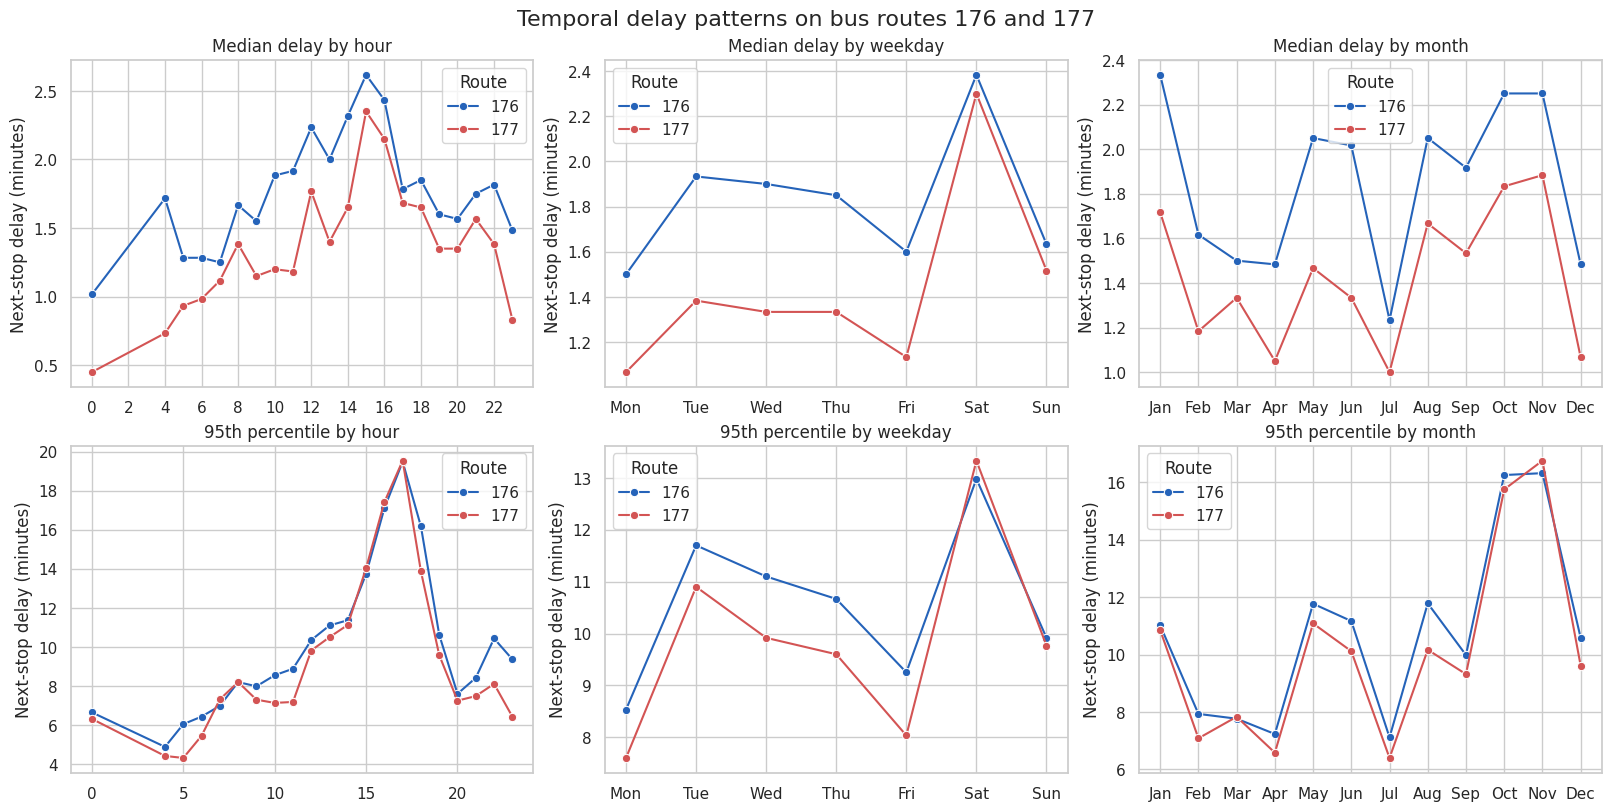

In [7]:
import calendar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

temporal_file = (
    PROCESSED_DIR
    / "model_dataset_176_177_2024_enriched.parquet"
)

# Load only the columns required for the figures
temporal_data = pd.read_parquet(
    temporal_file,
    columns=[
        "LineNumber",
        "scheduled_hour",
        "weekday",
        "month",
        "target_next_arrival_delay_min"
    ]
)

temporal_data["LineNumber"] = (
    temporal_data["LineNumber"].astype("string")
)

target = "target_next_arrival_delay_min"

def temporal_summary(column):
    return (
        temporal_data
        .groupby(["LineNumber", column], observed=True)
        .agg(
            observations=(target, "size"),
            median_delay=(target, "median"),
            p95_delay=(
                target,
                lambda values: values.quantile(0.95)
            )
        )
        .reset_index()
    )

hour_summary = temporal_summary("scheduled_hour")
weekday_summary = temporal_summary("weekday")
month_summary = temporal_summary("month")

weekday_names = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun"
}

weekday_summary["period"] = (
    weekday_summary["weekday"].map(weekday_names)
)

month_summary["period"] = (
    month_summary["month"]
    .astype(int)
    .map(lambda value: calendar.month_abbr[value])
)

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 8),
    constrained_layout=True
)

palette = {
    "176": "#2563B9",
    "177": "#D35454"
}

# Hour
sns.lineplot(
    data=hour_summary,
    x="scheduled_hour",
    y="median_delay",
    hue="LineNumber",
    palette=palette,
    marker="o",
    ax=axes[0, 0]
)

sns.lineplot(
    data=hour_summary,
    x="scheduled_hour",
    y="p95_delay",
    hue="LineNumber",
    palette=palette,
    marker="o",
    ax=axes[1, 0]
)

# Weekday
sns.lineplot(
    data=weekday_summary,
    x="period",
    y="median_delay",
    hue="LineNumber",
    palette=palette,
    marker="o",
    sort=False,
    ax=axes[0, 1]
)

sns.lineplot(
    data=weekday_summary,
    x="period",
    y="p95_delay",
    hue="LineNumber",
    palette=palette,
    marker="o",
    sort=False,
    ax=axes[1, 1]
)

# Month
sns.lineplot(
    data=month_summary,
    x="period",
    y="median_delay",
    hue="LineNumber",
    palette=palette,
    marker="o",
    sort=False,
    ax=axes[0, 2]
)

sns.lineplot(
    data=month_summary,
    x="period",
    y="p95_delay",
    hue="LineNumber",
    palette=palette,
    marker="o",
    sort=False,
    ax=axes[1, 2]
)

titles = [
    "Median delay by hour",
    "Median delay by weekday",
    "Median delay by month",
    "95th percentile by hour",
    "95th percentile by weekday",
    "95th percentile by month"
]

for axis, title in zip(axes.flat, titles):
    axis.set_title(title)
    axis.set_xlabel("")
    axis.set_ylabel("Next-stop delay (minutes)")
    axis.legend(title="Route")

axes[0, 0].set_xticks(range(0, 24, 2))

fig.suptitle(
    "Temporal delay patterns on bus routes 176 and 177",
    fontsize=16
)

figure_path = (
    FIGURES_DIR
    / "figure_temporal_delay_patterns.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", figure_path)

### Temporal delay patterns

Both routes show clear temporal variation. Delays generally increase during
the afternoon and reach their highest levels around 15:00–17:00. Saturdays
have the highest typical and upper-tail delays, while Fridays show lower
levels. Seasonal variation is also visible. Typical delays are relatively low
in July, whereas unusually large delays are most pronounced in October and
November. Route 176 generally has higher delays than route 177. The similar
temporal patterns support analysing the routes together, while their different
delay levels justify retaining route number as a model feature.


In [8]:
FIGURES_DIR = PROJECT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

figure_path = (
    FIGURES_DIR
    / "figure_temporal_delay_patterns.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

print("Figure saved to:", figure_path)

Figure saved to: /content/drive/MyDrive/AH2179_Final_Project_Bus_176_177/figures/figure_temporal_delay_patterns.png


In [9]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

warning_analysis = pd.DataFrame({
    "current_delay": (
        test_data["current_departure_delay_min"]
        .to_numpy()
    ),
    "actual_next_delay": y_test.to_numpy(),
    "predicted_next_delay": nn_test_prediction
})

# Actual and predicted change between current departure
# and arrival at the next stop
warning_analysis["actual_growth"] = (
    warning_analysis["actual_next_delay"]
    - warning_analysis["current_delay"]
)

warning_analysis["predicted_growth"] = (
    warning_analysis["predicted_next_delay"]
    - warning_analysis["current_delay"]
)

def warning_metrics(name, actual_event, predicted_event):
    return {
        "warning_type": name,
        "observations": len(actual_event),
        "actual_events": int(actual_event.sum()),
        "event_rate_percent": 100 * actual_event.mean(),
        "precision": precision_score(
            actual_event,
            predicted_event,
            zero_division=0
        ),
        "recall": recall_score(
            actual_event,
            predicted_event,
            zero_division=0
        ),
        "F1": f1_score(
            actual_event,
            predicted_event,
            zero_division=0
        )
    }

# Warning 1: delay grows by more than one minute
actual_growth_event = (
    warning_analysis["actual_growth"] > 1
)

predicted_growth_event = (
    warning_analysis["predicted_growth"] > 1
)

growth_metrics = warning_metrics(
    "Delay growth above 1 minute",
    actual_growth_event,
    predicted_growth_event
)

# Warning 2: bus crosses from at most 5 minutes
# to more than 5 minutes late
at_risk = warning_analysis["current_delay"] <= 5

actual_crossing = (
    warning_analysis.loc[
        at_risk,
        "actual_next_delay"
    ] > 5
)

predicted_crossing = (
    warning_analysis.loc[
        at_risk,
        "predicted_next_delay"
    ] > 5
)

crossing_metrics = warning_metrics(
    "New delay above 5 minutes",
    actual_crossing,
    predicted_crossing
)

warning_results = pd.DataFrame([
    growth_metrics,
    crossing_metrics
])

display(warning_results.round(3))

print("\nConfusion matrix: growth above 1 minute")
print(
    confusion_matrix(
        actual_growth_event,
        predicted_growth_event
    )
)

print("\nConfusion matrix: crossing 5 minutes")
print(
    confusion_matrix(
        actual_crossing,
        predicted_crossing
    )
)

,warning_type,observations,actual_events,event_rate_percent,precision,recall,F1
0,Delay growth above 1 minute,448566,14171,3.159,0.571,0.302,0.395
1,New delay above 5 minutes,361123,4398,1.218,0.659,0.438,0.526



Confusion matrix: growth above 1 minute
[[431179   3216]
 [  9887   4284]]

Confusion matrix: crossing 5 minutes
[[355727    998]
 [  2470   1928]]


### Early-warning performance

The next-stop regression model was also evaluated as an early-warning system.
A delay increase above one minute occurred in only 3.16% of the test
observations. The model achieved a precision of 57.1% but a recall of 30.2%,
indicating that its warnings were informative but that many delay-growth
events were missed.

Among buses currently delayed by no more than five minutes, only 1.22% crossed
the five-minute threshold at the next stop. The model identified these events
with 65.9% precision and 43.8% recall. Thus, approximately two out of three
warnings were correct, while fewer than half of all emerging delays were
detected. The model is therefore more suitable as a selective high-confidence
warning tool than as a comprehensive disruption-detection system.

In [10]:
from sklearn.metrics import precision_recall_curve

# Load October validation data only
validation_data = pd.read_parquet(
    ml_table_file,
    filters=[
        ("date", ">=", pd.Timestamp("2024-10-01")),
        ("date", "<", pd.Timestamp("2024-11-01"))
    ]
)

X_validation = validation_data[feature_columns]

X_validation_encoded = (
    linear_preprocessor.transform(X_validation)
)

validation_prediction = nn_model.predict(
    X_validation_encoded,
    batch_size=4096
).ravel()

y_validation = validation_data[
    "target_next_arrival_delay_min"
].to_numpy()

validation_current_delay = validation_data[
    "current_departure_delay_min"
].to_numpy()

validation_actual_growth = (
    y_validation - validation_current_delay
)

validation_predicted_growth = (
    validation_prediction - validation_current_delay
)

def select_f1_threshold(actual_event, scores):
    precision, recall, thresholds = (
        precision_recall_curve(actual_event, scores)
    )

    f1 = (
        2 * precision[:-1] * recall[:-1]
        / (
            precision[:-1]
            + recall[:-1]
            + 1e-12
        )
    )

    best_index = np.argmax(f1)

    return {
        "threshold": thresholds[best_index],
        "precision": precision[best_index],
        "recall": recall[best_index],
        "F1": f1[best_index]
    }

# Validation threshold for growth above one minute
growth_threshold_result = select_f1_threshold(
    validation_actual_growth > 1,
    validation_predicted_growth
)

# Validation threshold for crossing five minutes
validation_at_risk = validation_current_delay <= 5

crossing_threshold_result = select_f1_threshold(
    y_validation[validation_at_risk] > 5,
    validation_prediction[validation_at_risk]
)

selected_thresholds = pd.DataFrame([
    {
        "warning": "Growth above 1 minute",
        **growth_threshold_result
    },
    {
        "warning": "Crossing 5 minutes",
        **crossing_threshold_result
    }
])

display(selected_thresholds.round(3))

56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step


,warning,threshold,precision,recall,F1
0,Growth above 1 minute,0.595,0.436,0.485,0.459
1,Crossing 5 minutes,4.925,0.659,0.460,0.542


In [11]:
growth_threshold = growth_threshold_result["threshold"]
crossing_threshold = crossing_threshold_result["threshold"]

# Actual test events
test_actual_growth = (
    warning_analysis["actual_growth"] > 1
)

test_growth_warning = (
    warning_analysis["predicted_growth"]
    >= growth_threshold
)

test_at_risk = (
    warning_analysis["current_delay"] <= 5
)

test_actual_crossing = (
    warning_analysis.loc[
        test_at_risk,
        "actual_next_delay"
    ] > 5
)

test_crossing_warning = (
    warning_analysis.loc[
        test_at_risk,
        "predicted_next_delay"
    ] >= crossing_threshold
)

def test_warning_metrics(
    name,
    threshold,
    actual_event,
    predicted_event
):
    matrix = confusion_matrix(
        actual_event,
        predicted_event
    )

    tn, fp, fn, tp = matrix.ravel()

    return {
        "warning": name,
        "threshold": threshold,
        "observations": len(actual_event),
        "actual_events": int(actual_event.sum()),
        "warnings": int(predicted_event.sum()),
        "true_positive": int(tp),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "precision": precision_score(
            actual_event,
            predicted_event,
            zero_division=0
        ),
        "recall": recall_score(
            actual_event,
            predicted_event,
            zero_division=0
        ),
        "F1": f1_score(
            actual_event,
            predicted_event,
            zero_division=0
        )
    }

final_warning_results = pd.DataFrame([
    test_warning_metrics(
        "Growth above 1 minute",
        growth_threshold,
        test_actual_growth,
        test_growth_warning
    ),
    test_warning_metrics(
        "Crossing 5 minutes",
        crossing_threshold,
        test_actual_crossing,
        test_crossing_warning
    )
])

display(final_warning_results.round(3))

final_warning_results.to_csv(
    MODELS_DIR / "final_early_warning_results.csv",
    index=False
)

selected_thresholds.to_csv(
    MODELS_DIR / "validation_selected_warning_thresholds.csv",
    index=False
)

print("Final warning results saved.")

,warning,threshold,observations,actual_events,warnings,true_positive,false_positive,false_negative,precision,recall,F1
0,Growth above 1 minute,0.595,448566,14171,21074,7607,13467,6564,0.361,0.537,0.432
1,Crossing 5 minutes,4.925,361123,4398,3648,2168,1480,2230,0.594,0.493,0.539


Final warning results saved.


### Validation-selected warning thresholds

Warning thresholds were selected using the October validation period and then
applied unchanged to the November–December test period. Lowering the predicted
growth threshold to 0.595 minutes increased recall for actual growth events
from 30.2% to 53.7%, although precision decreased to 36.1%. This signal is
therefore better suited as a general risk indication.

For buses currently delayed by no more than five minutes, the validation-selected
threshold of 4.925 minutes detected 49.3% of the buses that crossed five minutes
at the next stop. Precision was 59.4% and F1 was 0.539. This represents the more
useful operational warning, although approximately half of the emerging delays
were still missed.

In [14]:
print("FEATURES USED BY THE SAVED MODEL")
print("--------------------------------")

for number, column in enumerate(
    feature_columns,
    start=1
):
    print(f"{number:02d}. {column}")

print("\nPOSSIBLE HISTORY COLUMNS IN TEST DATA")
print("-------------------------------------")

history_candidates = [
    column
    for column in test_data.columns
    if any(
        word in column.lower()
        for word in [
            "previous",
            "trend",
            "history",
            "lag",
            "change",
            "rolling"
        ]
    )
]

print(history_candidates)

FEATURES USED BY THE SAVED MODEL
--------------------------------
01. current_arrival_delay_min
02. current_departure_delay_min
03. observed_dwell_min
04. excess_dwell_min
05. next_segment_distance_km
06. stop_sequence
07. hour_sin
08. hour_cos
09. weekday_sin
10. weekday_cos
11. month_sin
12. month_cos
13. is_weekend
14. LineNumber
15. direction_id
16. current_stop_key
17. next_stop_key

POSSIBLE HISTORY COLUMNS IN TEST DATA
-------------------------------------
['previous_arrival_delay_min', 'delay_trend_min', 'history_available']


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

categorical_features_enhanced = [
    "LineNumber",
    "direction_id",
    "current_stop_key",
    "next_stop_key"
]

base_numeric_features = [
    column
    for column in feature_columns
    if column not in categorical_features_enhanced
]

history_features = [
    "previous_arrival_delay_min",
    "delay_trend_min",
    "history_available"
]

numeric_features_enhanced = (
    base_numeric_features
    + history_features
)

feature_columns_enhanced = (
    numeric_features_enhanced
    + categorical_features_enhanced
)

target_column = "target_next_arrival_delay_min"

required_columns = (
    ["date"]
    + feature_columns_enhanced
    + [target_column]
)

# Load only January–September and only required columns
train_enhanced = pd.read_parquet(
    ml_table_file,
    columns=required_columns,
    filters=[
        ("date", "<", pd.Timestamp("2024-10-01"))
    ]
)

# October and November–December are already loaded
validation_enhanced = validation_data[
    required_columns
].copy()

test_enhanced = test_data[
    required_columns
].copy()

print("MISSING VALUES")
print(
    train_enhanced[
        feature_columns_enhanced
    ].isna().sum().loc[
        lambda values: values > 0
    ]
)

enhanced_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(with_mean=False),
            numeric_features_enhanced
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                dtype=np.float32
            ),
            categorical_features_enhanced
        )
    ],
    sparse_threshold=1.0
)

print("\nTransforming enhanced training data...")

X_train_enhanced = (
    enhanced_preprocessor.fit_transform(
        train_enhanced[
            feature_columns_enhanced
        ]
    )
)

print("Transforming validation data...")

X_validation_enhanced = (
    enhanced_preprocessor.transform(
        validation_enhanced[
            feature_columns_enhanced
        ]
    )
)

print("Transforming test data...")

X_test_enhanced = (
    enhanced_preprocessor.transform(
        test_enhanced[
            feature_columns_enhanced
        ]
    )
)

y_train_enhanced = (
    train_enhanced[target_column]
    .astype("float32")
    .to_numpy()
)

y_validation_enhanced = (
    validation_enhanced[target_column]
    .astype("float32")
    .to_numpy()
)

y_test_enhanced = (
    test_enhanced[target_column]
    .astype("float32")
    .to_numpy()
)

print("\nENHANCED DATASET")
print("Features:", len(feature_columns_enhanced))
print("Training:", X_train_enhanced.shape)
print("Validation:", X_validation_enhanced.shape)
print("Test:", X_test_enhanced.shape)

print("\nAdded history features:")
for column in history_features:
    print("-", column)

MISSING VALUES
Series([], dtype: int64)

Transforming enhanced training data...
Transforming validation data...
Transforming test data...

ENHANCED DATASET
Features: 20
Training: (1966871, 220)
Validation: (228139, 220)
Test: (448566, 220)

Added history features:
- previous_arrival_delay_min
- delay_trend_min
- history_available


In [16]:
import gc
import time
import joblib
import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Remove unnecessary raw copies before training
del train_enhanced
del validation_enhanced
del test_enhanced
gc.collect()

np.random.seed(42)
tf.random.set_seed(42)

enhanced_model = keras.Sequential([
    keras.layers.Input(
        shape=(X_train_enhanced.shape[1],),
        sparse=True
    ),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1)
])

enhanced_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=keras.losses.Huber(),
    metrics=[
        keras.metrics.MeanAbsoluteError(
            name="mae"
        )
    ]
)

enhanced_model_path = (
    MODELS_DIR
    / "best_next_stop_delay_model_enhanced.keras"
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_mae",
        patience=3,
        mode="min",
        restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        str(enhanced_model_path),
        monitor="val_mae",
        mode="min",
        save_best_only=True
    )
]

training_start = time.time()

enhanced_history = enhanced_model.fit(
    X_train_enhanced,
    y_train_enhanced,
    validation_data=(
        X_validation_enhanced,
        y_validation_enhanced
    ),
    epochs=15,
    batch_size=4096,
    callbacks=callbacks,
    verbose=1
)

training_minutes = (
    time.time() - training_start
) / 60

enhanced_model = keras.models.load_model(
    str(enhanced_model_path)
)

enhanced_validation_prediction = (
    enhanced_model.predict(
        X_validation_enhanced,
        batch_size=4096
    ).ravel()
)

enhanced_test_prediction = (
    enhanced_model.predict(
        X_test_enhanced,
        batch_size=4096
    ).ravel()
)

def calculate_metrics(
    model_name,
    split,
    y_true,
    prediction
):
    return {
        "model": model_name,
        "split": split,
        "MAE_min": mean_absolute_error(
            y_true,
            prediction
        ),
        "RMSE_min": np.sqrt(
            mean_squared_error(
                y_true,
                prediction
            )
        ),
        "R2": r2_score(
            y_true,
            prediction
        )
    }

history_comparison = pd.DataFrame([
    calculate_metrics(
        "Original Keras",
        "Validation",
        y_validation_enhanced,
        validation_prediction
    ),
    calculate_metrics(
        "Enhanced Keras + history",
        "Validation",
        y_validation_enhanced,
        enhanced_validation_prediction
    ),
    calculate_metrics(
        "Original Keras",
        "Test",
        y_test_enhanced,
        nn_test_prediction
    ),
    calculate_metrics(
        "Enhanced Keras + history",
        "Test",
        y_test_enhanced,
        enhanced_test_prediction
    )
])

display(history_comparison.round(4))

original_test_mae = history_comparison.loc[
    (
        history_comparison["model"]
        == "Original Keras"
    )
    & (
        history_comparison["split"]
        == "Test"
    ),
    "MAE_min"
].iloc[0]

enhanced_test_mae = history_comparison.loc[
    (
        history_comparison["model"]
        == "Enhanced Keras + history"
    )
    & (
        history_comparison["split"]
        == "Test"
    ),
    "MAE_min"
].iloc[0]

improvement_percent = (
    100
    * (
        original_test_mae
        - enhanced_test_mae
    )
    / original_test_mae
)

print(
    "Training time:",
    round(training_minutes, 2),
    "minutes"
)

print(
    "Test MAE improvement:",
    round(improvement_percent, 2),
    "%"
)

joblib.dump(
    enhanced_preprocessor,
    MODELS_DIR
    / "next_stop_preprocessor_enhanced.joblib"
)

history_comparison.to_csv(
    MODELS_DIR
    / "keras_history_ablation_comparison.csv",
    index=False
)

print("Enhanced model and preprocessor saved.")

Epoch 1/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 28s 50ms/step - loss: 0.3379 - mae: 0.5619 - val_loss: 0.1582 - val_mae: 0.3531
Epoch 2/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 24s 50ms/step - loss: 0.0874 - mae: 0.2618 - val_loss: 0.1501 - val_mae: 0.3377
Epoch 3/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 24s 50ms/step - loss: 0.0846 - mae: 0.2554 - val_loss: 0.1470 - val_mae: 0.3311
Epoch 4/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - loss: 0.0832 - mae: 0.2521 - val_loss: 0.1455 - val_mae: 0.3277
Epoch 5/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - loss: 0.0823 - mae: 0.2498 - val_loss: 0.1445 - val_mae: 0.3256
Epoch 6/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - loss: 0.0816 - mae: 0.2480 - val_loss: 0.1436 - val_mae: 0.3236
Epoch 7/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - loss: 0.0810 - mae: 0.2467 - val_loss: 0.1427 - val_mae: 0.3216
Epoch 8/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - loss: 0.0805 - mae: 0.2457 - val_loss: 0.1421 - val_mae: 0.3203
Epoch 9/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 

,model,split,MAE_min,RMSE_min,R2
0,Original Keras,Validation,0.3185,1.5738,0.9620
1,Enhanced Keras + history,Validation,0.3142,1.5769,0.9619
2,Original Keras,Test,0.3477,1.5987,0.9574
3,Enhanced Keras + history,Test,0.3371,1.5970,0.9575


Training time: 7.25 minutes
Test MAE improvement: 3.05 %
Enhanced model and preprocessor saved.


### Historical-feature ablation

Adding previous arrival delay, recent delay trend and history availability
reduced the test MAE from 0.348 to 0.337 minutes, corresponding to a relative
improvement of 3.05%. Test RMSE and R² remained almost unchanged. The historical
variables therefore provide a small but consistent improvement for typical
next-stop predictions, while offering little improvement for the largest
errors. Their main potential value is expected in the detection of emerging
delay patterns rather than extreme disruptions.

In [17]:
from sklearn.metrics import (
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

validation_current = (
    validation_data[
        "current_departure_delay_min"
    ].to_numpy()
)

test_current = (
    test_data[
        "current_departure_delay_min"
    ].to_numpy()
)

# --------------------------------------------------
# Select thresholds using validation data
# --------------------------------------------------

validation_actual_growth = (
    y_validation_enhanced
    - validation_current
)

validation_enhanced_growth = (
    enhanced_validation_prediction
    - validation_current
)

def select_best_threshold(
    actual_event,
    prediction_score
):
    precision, recall, thresholds = (
        precision_recall_curve(
            actual_event,
            prediction_score
        )
    )

    f1 = (
        2 * precision[:-1] * recall[:-1]
        / (
            precision[:-1]
            + recall[:-1]
            + 1e-12
        )
    )

    best = np.argmax(f1)

    return {
        "threshold": thresholds[best],
        "validation_precision": precision[best],
        "validation_recall": recall[best],
        "validation_F1": f1[best]
    }

enhanced_growth_threshold = select_best_threshold(
    validation_actual_growth > 1,
    validation_enhanced_growth
)

validation_at_risk = validation_current <= 5

enhanced_crossing_threshold = select_best_threshold(
    (
        y_validation_enhanced[
            validation_at_risk
        ] > 5
    ),
    enhanced_validation_prediction[
        validation_at_risk
    ]
)

# --------------------------------------------------
# Apply thresholds once to test data
# --------------------------------------------------

test_actual_growth = (
    y_test_enhanced - test_current
)

test_predicted_growth = (
    enhanced_test_prediction - test_current
)

test_at_risk = test_current <= 5

def evaluate_warning(
    warning_name,
    threshold_information,
    actual_event,
    prediction_score
):
    threshold = threshold_information[
        "threshold"
    ]

    predicted_event = (
        prediction_score >= threshold
    )

    tn, fp, fn, tp = confusion_matrix(
        actual_event,
        predicted_event
    ).ravel()

    return {
        "warning": warning_name,
        "threshold": threshold,
        "observations": len(actual_event),
        "actual_events": int(actual_event.sum()),
        "warnings": int(predicted_event.sum()),
        "true_positive": int(tp),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "precision": precision_score(
            actual_event,
            predicted_event,
            zero_division=0
        ),
        "recall": recall_score(
            actual_event,
            predicted_event,
            zero_division=0
        ),
        "F1": f1_score(
            actual_event,
            predicted_event,
            zero_division=0
        )
    }

enhanced_warning_results = pd.DataFrame([
    evaluate_warning(
        "Growth above 1 minute",
        enhanced_growth_threshold,
        test_actual_growth > 1,
        test_predicted_growth
    ),
    evaluate_warning(
        "Crossing 5 minutes",
        enhanced_crossing_threshold,
        (
            y_test_enhanced[
                test_at_risk
            ] > 5
        ),
        enhanced_test_prediction[
            test_at_risk
        ]
    )
])

print("VALIDATION-SELECTED THRESHOLDS")

display(
    pd.DataFrame([
        {
            "warning": "Growth above 1 minute",
            **enhanced_growth_threshold
        },
        {
            "warning": "Crossing 5 minutes",
            **enhanced_crossing_threshold
        }
    ]).round(3)
)

print("\nENHANCED MODEL – TEST RESULTS")
display(enhanced_warning_results.round(3))

enhanced_warning_results.to_csv(
    MODELS_DIR
    / "enhanced_keras_early_warning_results.csv",
    index=False
)

VALIDATION-SELECTED THRESHOLDS


,warning,threshold,validation_precision,validation_recall,validation_F1
0,Growth above 1 minute,0.733,0.534,0.520,0.527
1,Crossing 5 minutes,4.899,0.638,0.482,0.549



ENHANCED MODEL – TEST RESULTS


,warning,threshold,observations,actual_events,warnings,true_positive,false_positive,false_negative,precision,recall,F1
0,Growth above 1 minute,0.733,448566,14171,16434,7515,8919,6656,0.457,0.530,0.491
1,Crossing 5 minutes,4.899,361123,4398,4125,2328,1797,2070,0.564,0.529,0.546


### Effect of historical delay information

Adding previous delay information improved both regression accuracy and
early-warning performance. Test MAE decreased by 3.05%. For delay growth above
one minute, test F1 increased from 0.432 to 0.491, while false-positive warnings
decreased from 13,467 to 8,919 with almost unchanged recall. For crossing the
five-minute delay threshold, F1 increased slightly from 0.539 to 0.546 and
recall increased to 52.9%. The enhanced neural network was therefore selected
as the final model.

Baseline sample MAE: 0.3454 minutes


,feature_group,MAE_increase_min,MAE_increase_sec,std_sec
0,Current delay,3.2009,192.0519,1.5528
1,Previous delay pattern,1.7472,104.8304,0.1664
2,Stop location,0.4517,27.1037,0.0902
3,Dwell time,0.1692,10.1534,0.0861
4,Route and direction,0.0516,3.0954,0.0493
5,Time of day,0.0306,1.8338,0.0339
6,Segment and sequence,0.0180,1.0813,0.0215
7,Day of week,0.0163,0.9762,0.0252
8,Month,0.0001,0.0060,0.0177


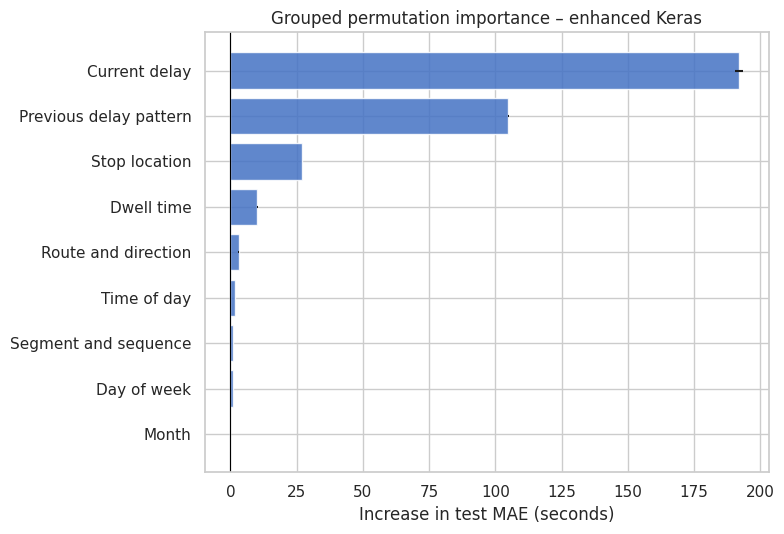

In [18]:
from sklearn.metrics import mean_absolute_error

rng = np.random.default_rng(42)

sample_size = min(
    15_000,
    len(test_data)
)

sample_positions = np.sort(
    rng.choice(
        len(test_data),
        size=sample_size,
        replace=False
    )
)

X_importance = (
    test_data.iloc[sample_positions]
    [feature_columns_enhanced]
    .reset_index(drop=True)
)

y_importance = (
    y_test_enhanced[sample_positions]
)

baseline_prediction = (
    enhanced_test_prediction[
        sample_positions
    ]
)

baseline_mae = mean_absolute_error(
    y_importance,
    baseline_prediction
)

feature_groups = {
    "Current delay": [
        "current_arrival_delay_min",
        "current_departure_delay_min"
    ],
    "Previous delay pattern": [
        "previous_arrival_delay_min",
        "delay_trend_min",
        "history_available"
    ],
    "Dwell time": [
        "observed_dwell_min",
        "excess_dwell_min"
    ],
    "Stop location": [
        "current_stop_key",
        "next_stop_key"
    ],
    "Route and direction": [
        "LineNumber",
        "direction_id"
    ],
    "Segment and sequence": [
        "next_segment_distance_km",
        "stop_sequence"
    ],
    "Time of day": [
        "hour_sin",
        "hour_cos"
    ],
    "Day of week": [
        "weekday_sin",
        "weekday_cos",
        "is_weekend"
    ],
    "Month": [
        "month_sin",
        "month_cos"
    ]
}

importance_rows = []

for group_name, columns in feature_groups.items():
    increases = []

    for repetition in range(3):
        permutation = rng.permutation(
            sample_size
        )

        permuted_data = X_importance.copy()

        for column in columns:
            permuted_data[column] = (
                X_importance[column]
                .iloc[permutation]
                .to_numpy()
            )

        permuted_encoded = (
            enhanced_preprocessor.transform(
                permuted_data
            )
        )

        permuted_prediction = (
            enhanced_model.predict(
                permuted_encoded,
                batch_size=4096,
                verbose=0
            ).ravel()
        )

        permuted_mae = mean_absolute_error(
            y_importance,
            permuted_prediction
        )

        increases.append(
            permuted_mae - baseline_mae
        )

    importance_rows.append({
        "feature_group": group_name,
        "MAE_increase_min": np.mean(increases),
        "std_min": np.std(increases)
    })

grouped_importance = (
    pd.DataFrame(importance_rows)
    .sort_values(
        "MAE_increase_min",
        ascending=False
    )
    .reset_index(drop=True)
)

grouped_importance["MAE_increase_sec"] = (
    60
    * grouped_importance[
        "MAE_increase_min"
    ]
)

grouped_importance["std_sec"] = (
    60
    * grouped_importance["std_min"]
)

print(
    "Baseline sample MAE:",
    round(baseline_mae, 4),
    "minutes"
)

display(
    grouped_importance[
        [
            "feature_group",
            "MAE_increase_min",
            "MAE_increase_sec",
            "std_sec"
        ]
    ].round(4)
)

plot_data = grouped_importance.sort_values(
    "MAE_increase_sec"
)

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.barh(
    plot_data["feature_group"],
    plot_data["MAE_increase_sec"],
    xerr=plot_data["std_sec"],
    color="#4472C4",
    alpha=0.85
)

ax.axvline(
    0,
    color="black",
    linewidth=0.8
)

ax.set_xlabel(
    "Increase in test MAE (seconds)"
)

ax.set_ylabel("")
ax.set_title(
    "Grouped permutation importance – enhanced Keras"
)

plt.tight_layout()

FIGURES_DIR = PROJECT_DIR / "figures"
FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    FIGURES_DIR
    / "figure_enhanced_grouped_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

grouped_importance.to_csv(
    MODELS_DIR
    / "enhanced_keras_grouped_importance.csv",
    index=False
)

### Model interpretation

Grouped permutation importance showed that the current arrival and departure
delay were the dominant predictors of next-stop delay. Previous delay and
recent delay trend formed the second most important group, demonstrating that
the model also uses the trajectory of the delay. Stop location and dwell time
provided additional predictive information, while route, direction and
calendar variables had smaller conditional contributions.

Although monthly delay patterns were visible in the descriptive analysis,
month had almost no additional permutation importance after the current
operational state and location were included. This means that seasonal
variation helps describe the system but contributes little to an individual
next-stop prediction.

Permutation importance should not be interpreted causally or as the independent
improvement produced by each feature group. The controlled ablation showed
that adding historical variables reduced test MAE by 3.05%, while the larger
permutation effect indicates that the enhanced model relies strongly on these
correlated historical signals.